# Module 4 - VSCMG Dynamics

Variable-Speed Control Moment Gyroscopes (VSCMGs) combine the operating principles of **reaction wheels (RWs)** and **control moment gyroscopes (CMGs)**. By controlling both rotor spin speed and gimbal motion, a VSCMG can exchange angular momentum with the spacecraft through two independent actuator motions.

The basic mechanics of momentum-exchange devices were developed in the first *Spacecraft Dynamics and Control* specialization. This module builds on that foundation by revisiting the single-VSCMG model compactly, then extending it to the numerical modeling of spacecraft carrying multiple VSCMGs.

The development follows the progression

$$
\boxed{
\text{geometry and moving frames}
\;\rightarrow\;
\text{inertia and angular momentum}
\;\rightarrow\;
\text{equations of motion}
\;\rightarrow\;
\text{motor torques}
\;\rightarrow\;
\text{numerical simulation}
}
$$

The single-VSCMG model is developed first from its geometry and momentum relations. Reaction-wheel and CMG behavior then appear naturally as special cases of the general VSCMG formulation. The same device-level model is subsequently extended to multiple VSCMGs, with particular attention given to numerical implementation, simulation, and verification using the work-energy principle.

This notebook therefore focuses on **reconstructing, implementing, and verifying** the dynamics rather than repeating the full derivations developed previously.

> **Prior material:**  
> [Specialization 1, Course 2, Module 4 - Equations of Motion with Momentum Exchange Devices](https://github.com/johnm3398/Spacecraft-Dynamics-and-Control/blob/main/01_spacecraft_dynamics_and_control_specialization/02_kinetics/Module%204%20-%20Equations%20of%20Motion%20with%20Momentum%20Exchange%20Devices.ipynb)  
> [Specialization 1, Course 2 - Momentum Exchange Devices Slides](https://github.com/johnm3398/Spacecraft-Dynamics-and-Control/blob/main/01_spacecraft_dynamics_and_control_specialization/02_kinetics/Slides/5%20-%20Momentum%20Exchange%20Devices.pdf)

In [1]:
import numpy as np

from scipy.integrate import solve_ivp

import matplotlib.pyplot as plt

import sys
sys.path.insert(0, r"../../")
import AttitudeKinematicsLib as ak

# 1 - Single VSCMG Modeling

## 1.1 - Momentum Exchange Devices and the VSCMG

A **momentum exchange device** controls spacecraft rotation by exchanging angular momentum between an internal rotating assembly and the spacecraft body.

In the absence of external torque, the total angular momentum of the spacecraft-device system is conserved. The actuator therefore does not create angular momentum; instead, an internal motor changes the momentum stored in the device and the spacecraft body responds with an equal and opposite change.

Conceptually,

$$
\boxed{
\text{change device angular momentum}
\;\Longleftrightarrow\;
\text{change spacecraft angular momentum}
}
$$

The three devices of interest differ primarily in **how the internal angular momentum is changed**:

- A **reaction wheel (RW)** has a fixed spin axis. Control is generated by changing the rotor spin rate and therefore the magnitude of its angular momentum.
- A **control moment gyroscope (CMG)** typically maintains a large rotor spin rate and generates control torque by gimbaling the rotor, thereby changing the **direction** of its angular momentum.
- A **variable-speed control moment gyroscope (VSCMG)** allows both the rotor speed and gimbal angle to vary.

A VSCMG therefore combines the two actuation mechanisms:

$$
\boxed{
\dot{\Omega}
\;\rightarrow\;
\text{change momentum magnitude}
}
$$

and

$$
\boxed{
\dot{\gamma}
\;\rightarrow\;
\text{change momentum direction}.
}
$$

This makes the VSCMG the most general of the three models. Reaction-wheel and conventional CMG behavior can later be recovered as special cases by restricting one of these internal motions.

The first step in constructing its equations of motion is therefore to define the geometry of the rotating assembly and the moving basis vectors attached to it.

## 1.2 - VSCMG Geometry and Moving Frames

A VSCMG has two internal motions going on at the same time: the rotor spins about its own axis, while the gimbal rotates that whole rotor assembly about a second axis.

It is easiest to keep track of all of this using the three orthogonal directions shown below.

<img src="Images/VSCMG_Frame.PNG" alt="VSCMG Frame" width="500" align="left" style="margin-right: 20px;"/>

- <ins>**Spin axis**</ins> ($\hat{\mathbf g}_s$)  
  The axis the rotor actually spins about. The rotor spin rate about this axis is $\Omega$.

- <ins>**Gimbal axis**</ins> ($\hat{\mathbf g}_g$)  
  The axis about which the entire rotor-gimbal assembly rotates. This axis is fixed relative to the spacecraft body frame $\mathcal{B}$.

- <ins>**Transverse axis**</ins> ($\hat{\mathbf g}_t$)  
  The third direction needed to complete the right-handed orthonormal triad,

  $$
  \hat{\mathbf g}_t = \hat{\mathbf g}_g \times \hat{\mathbf g}_s.
  $$

- <ins>**Rotor spin rate**</ins> ($\Omega$)  
  The angular velocity of the rotor relative to the gimbal frame about $\hat{\mathbf g}_s$.

- <ins>**Gimbal angle**</ins> ($\gamma$)  
  Describes how far the gimbal has rotated about $\hat{\mathbf g}_g$.

- <ins>**Gimbal rate**</ins> ($\dot{\gamma}$)  
  The angular velocity of the gimbal frame relative to the spacecraft body.

- <ins>**Gimbal frame**</ins> ($\mathcal{G}$)

  $$
  \mathcal{G} =
  \left\{
  \hat{\mathbf g}_s,\,
  \hat{\mathbf g}_t,\,
  \hat{\mathbf g}_g
  \right\}.
  $$

  These three unit vectors define the moving coordinate frame attached to the gimbal assembly.

<br clear="left"/>

The key thing to notice is that $\hat{\mathbf g}_g$ stays fixed in the spacecraft body, while $\hat{\mathbf g}_s$ and $\hat{\mathbf g}_t$ rotate around it as the gimbal moves.

The angular velocity of the gimbal frame relative to the spacecraft body is therefore

$$
\boxed{
\boldsymbol{\omega}_{G/B} = \dot{\gamma}\, \hat{\mathbf g}_g.
}
$$

The rotor then has another rotation on top of this: it spins relative to the gimbal frame about $\hat{\mathbf g}_s$,

$$
\boxed{
\boldsymbol{\omega}_{W/G} = \Omega\, \hat{\mathbf g}_s.
}
$$

So there are really two nested rotations taking place:

$$
\boxed{
\mathcal{B}
\;\xrightarrow{\;\dot{\gamma}\hat{\mathbf g}_g\;}
\mathcal{G}
\;\xrightarrow{\;\Omega\hat{\mathbf g}_s\;}
\mathcal{W}.
}
$$

Here, $\mathcal{B}$ is the spacecraft body frame, $\mathcal{G}$ is the gimbal frame, and $\mathcal{W}$ is the spinning rotor frame.

**<ins>How the Gimbal-Frame Axes Move</ins>**

The vectors $\hat{\mathbf g}_s$, $\hat{\mathbf g}_t$, and $\hat{\mathbf g}_g$ are fixed when viewed from $\mathcal G$ itself. From the spacecraft body, though, the spin and transverse axes turn as the gimbal moves. Let's write that motion down before taking any derivatives.

Choose a reference time $t_0$, and let $\gamma_0=\gamma(t_0)$. The change in gimbal angle is $\Delta\gamma=\gamma(t)-\gamma_0$. With every axis written in **body-frame components**,

$$
\begin{aligned}
\hat{\mathbf g}_s(t) &= \cos(\Delta\gamma)\hat{\mathbf g}_s(t_0)
    + \sin(\Delta\gamma)\hat{\mathbf g}_t(t_0), \\
\hat{\mathbf g}_t(t) &= -\sin(\Delta\gamma)\hat{\mathbf g}_s(t_0)
    + \cos(\Delta\gamma)\hat{\mathbf g}_t(t_0), \\
\hat{\mathbf g}_g(t) &= \hat{\mathbf g}_g(t_0).
\end{aligned}
$$

The initial columns on the right are constant body-coordinate directions. These equations describe the axes turning inside the spacecraft; they do not yet include the spacecraft's own rotation relative to inertial space.

**Differentiate the geometry in the body frame.** Since $d(\Delta\gamma)/dt=\dot{\gamma}$,

$$
\begin{aligned}
{}^B\frac{d\hat{\mathbf g}_s}{dt}
&= \dot{\gamma}\left[-\sin(\Delta\gamma)\hat{\mathbf g}_s(t_0)
    + \cos(\Delta\gamma)\hat{\mathbf g}_t(t_0)\right] \\
&= \dot{\gamma}\hat{\mathbf g}_t,
\end{aligned}
$$

and

$$
\begin{aligned}
{}^B\frac{d\hat{\mathbf g}_t}{dt}
&= -\dot{\gamma}\left[\cos(\Delta\gamma)\hat{\mathbf g}_s(t_0)
    + \sin(\Delta\gamma)\hat{\mathbf g}_t(t_0)\right] \\
&= -\dot{\gamma}\hat{\mathbf g}_s.
\end{aligned}
$$

The gimbal axis stays fixed in the body, so ${}^B d\hat{\mathbf g}_g/dt=\mathbf 0$.

**The same result from the transport theorem.** For any gimbal-fixed basis vector, indexed by $i=s,t,g$,

$$
\begin{aligned}
{}^B\frac{d\hat{\mathbf g}_i}{dt}
&= {}^G\frac{d\hat{\mathbf g}_i}{dt}
    + \boldsymbol{\omega}_{G/B}\times\hat{\mathbf g}_i \\
&= \mathbf 0 + \dot{\gamma}\hat{\mathbf g}_g\times\hat{\mathbf g}_i.
\end{aligned}
$$

The signs follow from the right-handed triad:

$$
\begin{aligned}
\hat{\mathbf g}_g\times\hat{\mathbf g}_s &= \hat{\mathbf g}_t, \\
\hat{\mathbf g}_g\times\hat{\mathbf g}_t &= -\hat{\mathbf g}_s, \\
\hat{\mathbf g}_g\times\hat{\mathbf g}_g &= \mathbf 0.
\end{aligned}
$$

So the three body-frame rates are

$$
\boxed{
\begin{aligned}
{}^B\frac{d\hat{\mathbf g}_s}{dt} &= \dot{\gamma}\hat{\mathbf g}_t, \\
{}^B\frac{d\hat{\mathbf g}_t}{dt} &= -\dot{\gamma}\hat{\mathbf g}_s, \\
{}^B\frac{d\hat{\mathbf g}_g}{dt} &= \mathbf 0.
\end{aligned}
}
$$

This is the geometry behind CMG action: gimbaling turns the spin axis toward the transverse axis. Later, when that axis carries wheel angular momentum, its motion will produce a transverse momentum-rate term. First we need to work out exactly how much momentum each part carries.


## 1.3 - VSCMG Inertia and System Angular Momentum

With the geometry sorted out, the next step is to build the angular momentum of the full spacecraft-device system:

$$
\mathbf H = \mathbf H_B + \mathbf H_G + \mathbf H_W.
$$

Here $\mathbf H_B$ is the spacecraft-body contribution, $\mathbf H_G$ is the gimbal contribution, and $\mathbf H_W$ is the wheel contribution. Once we have all three, the dynamics follow from

$$
{}^N\frac{d\mathbf H}{dt} = \mathbf L,
$$

where $\mathcal N$ is the inertial frame and $\mathbf L$ is the net external torque about the complete system's center of mass.

We use the balanced-device model underlying the reference derivation. The device centers stay fixed in the body, and the separately modeled gimbal and wheel inertias describe rotation about their own centers. Any constant contributions from their offsets are included once in the spacecraft inertia $[I_s]$. We'll keep that bookkeeping explicit when we write $\mathbf H_B$.

For now, there are two jobs: express the inertias in a common frame, then apply each inertia to the **inertial angular velocity of that part**.

**Main mathematical reference:** [Momentum Exchange Devices](../../01_spacecraft_dynamics_and_control_specialization/02_kinetics/Slides/5%20-%20Momentum%20Exchange%20Devices.pdf), slides 14–27 for the single-VSCMG development and slides 29–32 for motor torques. The derivation below fills in the intermediate steps and ends with the grouping used on slide 27.


**<ins>Gimbal and Wheel Inertias</ins>**

The gimbal axes are principal axes of the gimbal assembly, so its inertia matrix in $\mathcal G$ is

$$
{}^G[I_G] =
\begin{bmatrix}
I_{G_s} & 0 & 0 \\
0 & I_{G_t} & 0 \\
0 & 0 & I_{G_g}
\end{bmatrix}.
$$

The wheel is axisymmetric about its spin axis. Its spin moment is $I_{W_s}$, and both transverse moments are $I_{W_t}$:

$$
{}^W[I_W] =
\begin{bmatrix}
I_{W_s} & 0 & 0 \\
0 & I_{W_t} & 0 \\
0 & 0 & I_{W_t}
\end{bmatrix}.
$$

That repeated transverse moment is useful: rotating the wheel about its spin axis leaves its inertia unchanged. We can see this directly from the transformation between $\mathcal W$ and $\mathcal G$.

Let $\theta$ be the wheel's positive spin angle relative to the gimbal, with $\dot{\theta}=\Omega$. The direction cosine matrix mapping wheel components to gimbal components is

$$
[GW] =
\begin{bmatrix}
1 & 0 & 0 \\
0 & \cos\theta & -\sin\theta \\
0 & \sin\theta & \cos\theta
\end{bmatrix}.
$$

Apply the tensor transformation:

$$
\begin{aligned}
{}^G[I_W] &= [GW]\,{}^W[I_W]\,[GW]^T \\
&=
\begin{bmatrix}
I_{W_s} & 0 & 0 \\
0 & I_{W_t}(\cos^2\theta+\sin^2\theta)
  & I_{W_t}(\cos\theta\sin\theta-\sin\theta\cos\theta) \\
0 & I_{W_t}(\sin\theta\cos\theta-\cos\theta\sin\theta)
  & I_{W_t}(\sin^2\theta+\cos^2\theta)
\end{bmatrix} \\
&=
\begin{bmatrix}
I_{W_s} & 0 & 0 \\
0 & I_{W_t} & 0 \\
0 & 0 & I_{W_t}
\end{bmatrix}.
\end{aligned}
$$

Thus,

$$
\boxed{{}^G[I_W] = {}^W[I_W].}
$$

The frames still rotate relative to one another; it is the **wheel-inertia matrix** that stays numerically the same. This lets us describe both device inertias using the gimbal axes without tracking the wheel's transverse axes through every spin revolution.


**<ins>Inertias in the Spacecraft Body Frame</ins>**

This inertia transformation follows [slide 17](../../01_spacecraft_dynamics_and_control_specialization/02_kinetics/Slides/5%20-%20Momentum%20Exchange%20Devices.pdf#page=17). Matrix products need all component arrays expressed in the same frame. In this subsection the matrices and axis columns use body components unless a left superscript says otherwise. Later, the momentum and derivative vectors are resolved directly along the gimbal basis, as in the slides; writing those vector sums requires no additional frame conversion.

The columns of the gimbal-to-body direction cosine matrix are the gimbal axes written in body components:

$$
[BG] =
\begin{bmatrix}
{}^B\hat{\mathbf g}_s & {}^B\hat{\mathbf g}_t & {}^B\hat{\mathbf g}_g
\end{bmatrix}.
$$

For any vector $\mathbf v$, this means ${}^B\mathbf v=[BG] {}^G\mathbf v$. Below, we omit the ${}^B$ superscript on the axis columns to keep the expressions readable.

Transform the gimbal inertia using the same matrix on both sides:

$$
\begin{aligned}
{}^B[I_G] &= [BG] {}^G[I_G] [BG]^T \\
&=
\begin{bmatrix}
I_{G_s}\hat{\mathbf g}_s & I_{G_t}\hat{\mathbf g}_t & I_{G_g}\hat{\mathbf g}_g
\end{bmatrix}
\begin{bmatrix}
\hat{\mathbf g}_s^T \\
\hat{\mathbf g}_t^T \\
\hat{\mathbf g}_g^T
\end{bmatrix} \\
&= I_{G_s}\hat{\mathbf g}_s\hat{\mathbf g}_s^T
    + I_{G_t}\hat{\mathbf g}_t\hat{\mathbf g}_t^T
    + I_{G_g}\hat{\mathbf g}_g\hat{\mathbf g}_g^T.
\end{aligned}
$$

Each outer product picks out one principal direction. For example, $\hat{\mathbf g}_s\hat{\mathbf g}_s^T\mathbf v$ projects $\mathbf v$ onto the spin axis and returns that projected vector.

The wheel transforms in exactly the same way, using the gimbal-frame matrix established above:

$$
\begin{aligned}
{}^B[I_W] &= [BG] {}^G[I_W] [BG]^T \\
&= I_{W_s}\hat{\mathbf g}_s\hat{\mathbf g}_s^T
    + I_{W_t}\hat{\mathbf g}_t\hat{\mathbf g}_t^T
    + I_{W_t}\hat{\mathbf g}_g\hat{\mathbf g}_g^T.
\end{aligned}
$$

From here on, $[I_G]$ and $[I_W]$ without component superscripts mean these body-frame matrices. Their principal moments are constant, but the outer products generally change as the gimbal turns.


**<ins>Body Rate Resolved Along the VSCMG Axes</ins>**

Let $\boldsymbol{\omega}\equiv\boldsymbol{\omega}_{B/N}$ be the spacecraft angular velocity relative to inertial space. We can resolve this same vector along either the body axes or the gimbal axes. For the device algebra, the gimbal directions are more convenient:

$$
\begin{aligned}
\omega_s &= \hat{\mathbf g}_s^T\boldsymbol{\omega}, \\
\omega_t &= \hat{\mathbf g}_t^T\boldsymbol{\omega}, \\
\omega_g &= \hat{\mathbf g}_g^T\boldsymbol{\omega}.
\end{aligned}
$$

These are scalar projections, so the reconstructed vector is

$$
\boxed{
\boldsymbol{\omega}
= \omega_s\hat{\mathbf g}_s + \omega_t\hat{\mathbf g}_t + \omega_g\hat{\mathbf g}_g.
}
$$

In coordinate form, the same relationship is

$$
{}^G\boldsymbol{\omega}=
\begin{bmatrix}
\omega_s \\ \omega_t \\ \omega_g
\end{bmatrix},
\qquad
{}^B\boldsymbol{\omega}=[BG] {}^G\boldsymbol{\omega}.
$$

Nothing about the physical angular velocity has changed. We have just chosen directions that make the device inertia multiplications easier to read. In particular, $\omega_s$ is the **body rate projected onto the spin axis**; it is distinct from the relative wheel spin rate $\Omega$.


**<ins>Spacecraft Angular Momentum</ins>**

The spacecraft body contribution is just the usual rigid-body result:

$$
\boxed{ \mathbf H_B = [I_s]\boldsymbol{\omega}. }
$$

Here, $[I_s]$ is the inertia of the spacecraft body excluding the gimbal and wheel inertias that are being modeled separately.

> **Reference consistency note:** the older angular-momentum section calls $[I_s]$ the inertia of the entire spacecraft including internal components, but its later EOM adds $[I_G]+[I_W]$ separately. Here, the gimbal and wheel rotational inertias are excluded from $[I_s]$, as required by that later derivation; fixed mass-offset contributions remain included once.


**<ins>Gimbal Angular Momentum</ins>**

Start with the gimbal's rigid-body momentum relation:

$$
\mathbf H_G=[I_G]\boldsymbol{\omega}_{G/N}.
$$

The angular velocity here must include the motion inherited from the spacecraft. Adding the two relative rotations gives

$$
\begin{aligned}
\boldsymbol{\omega}_{G/N}
&= \boldsymbol{\omega}_{G/B}+\boldsymbol{\omega}_{B/N} \\
&= \dot{\gamma}\hat{\mathbf g}_g+\boldsymbol{\omega} \\
&= \omega_s\hat{\mathbf g}_s+\omega_t\hat{\mathbf g}_t
    +(\omega_g+\dot{\gamma})\hat{\mathbf g}_g.
\end{aligned}
$$

All terms are vectors expressed in the same body components. Now substitute the dyadic inertia and distribute the multiplication:

$$
\begin{aligned}
\mathbf H_G
&= \left(I_{G_s}\hat{\mathbf g}_s\hat{\mathbf g}_s^T
    +I_{G_t}\hat{\mathbf g}_t\hat{\mathbf g}_t^T
    +I_{G_g}\hat{\mathbf g}_g\hat{\mathbf g}_g^T\right)
    (\boldsymbol{\omega}+\dot{\gamma}\hat{\mathbf g}_g) \\
&= [I_G]\boldsymbol{\omega}+[I_G](\dot{\gamma}\hat{\mathbf g}_g).
\end{aligned}
$$

**The body-rotation contribution.** Each outer product extracts the corresponding body-rate projection:

$$
\begin{aligned}
[I_G]\boldsymbol{\omega}
&= I_{G_s}\hat{\mathbf g}_s(\hat{\mathbf g}_s^T\boldsymbol{\omega})
    +I_{G_t}\hat{\mathbf g}_t(\hat{\mathbf g}_t^T\boldsymbol{\omega})
    +I_{G_g}\hat{\mathbf g}_g(\hat{\mathbf g}_g^T\boldsymbol{\omega}) \\
&= I_{G_s}\omega_s\hat{\mathbf g}_s
    +I_{G_t}\omega_t\hat{\mathbf g}_t
    +I_{G_g}\omega_g\hat{\mathbf g}_g.
\end{aligned}
$$

**The relative gimbal contribution.** Here orthogonality eliminates the spin and transverse terms:

$$
\begin{aligned}
[I_G](\dot{\gamma}\hat{\mathbf g}_g)
&= I_{G_s}\dot{\gamma}\hat{\mathbf g}_s
    \underbrace{(\hat{\mathbf g}_s^T\hat{\mathbf g}_g)}_{0} \\
&\quad +I_{G_t}\dot{\gamma}\hat{\mathbf g}_t
    \underbrace{(\hat{\mathbf g}_t^T\hat{\mathbf g}_g)}_{0} \\
&\quad +I_{G_g}\dot{\gamma}\hat{\mathbf g}_g
    \underbrace{(\hat{\mathbf g}_g^T\hat{\mathbf g}_g)}_{1} \\
&= I_{G_g}\dot{\gamma}\hat{\mathbf g}_g.
\end{aligned}
$$

Add the two contributions and collect the gimbal-axis rate:

$$
\boxed{
\mathbf H_G = I_{G_s}\omega_s\hat{\mathbf g}_s
    +I_{G_t}\omega_t\hat{\mathbf g}_t
    +I_{G_g}(\omega_g+\dot{\gamma})\hat{\mathbf g}_g.
}
$$

The gimbal carries momentum even when its motor is holding it still relative to the body. The $\omega_s$, $\omega_t$, and $\omega_g$ terms come from being carried around by the spacecraft; $\dot{\gamma}$ adds the relative motion about its own axis.


**<ins>Wheel Angular Momentum</ins>**

The wheel inherits the same spacecraft and gimbal motions, then adds its spin relative to $\mathcal G$:

$$
\begin{aligned}
\boldsymbol{\omega}_{W/N}
&= \boldsymbol{\omega}_{W/G}+\boldsymbol{\omega}_{G/B}+\boldsymbol{\omega}_{B/N} \\
&= \Omega\hat{\mathbf g}_s+\dot{\gamma}\hat{\mathbf g}_g+\boldsymbol{\omega} \\
&= (\omega_s+\Omega)\hat{\mathbf g}_s+\omega_t\hat{\mathbf g}_t
    +(\omega_g+\dot{\gamma})\hat{\mathbf g}_g.
\end{aligned}
$$

As before, multiply by the inertia of that part, and keep the three motions separate for a moment:

$$
\begin{aligned}
\mathbf H_W &= [I_W]\boldsymbol{\omega}_{W/N} \\
&= [I_W]\boldsymbol{\omega}
    +[I_W](\dot{\gamma}\hat{\mathbf g}_g)
    +[I_W](\Omega\hat{\mathbf g}_s).
\end{aligned}
$$

**1. Momentum carried by the body rotation.** The same dyadic multiplication used for the gimbal gives

$$
\begin{aligned}
[I_W]\boldsymbol{\omega}
&= \left(I_{W_s}\hat{\mathbf g}_s\hat{\mathbf g}_s^T
    +I_{W_t}\hat{\mathbf g}_t\hat{\mathbf g}_t^T
    +I_{W_t}\hat{\mathbf g}_g\hat{\mathbf g}_g^T\right)\boldsymbol{\omega} \\
&= I_{W_s}\omega_s\hat{\mathbf g}_s
    +I_{W_t}\omega_t\hat{\mathbf g}_t
    +I_{W_t}\omega_g\hat{\mathbf g}_g.
\end{aligned}
$$

**2. Momentum from relative gimbal motion.** In $\mathcal G$, this angular velocity has only a third component. Multiply there, then map the resulting column back to body components:

$$
\begin{aligned}
[I_W](\dot{\gamma}\hat{\mathbf g}_g)
&= [BG]
\begin{bmatrix}
I_{W_s} & 0 & 0 \\
0 & I_{W_t} & 0 \\
0 & 0 & I_{W_t}
\end{bmatrix}
\begin{bmatrix}
0 \\ 0 \\ \dot{\gamma}
\end{bmatrix} \\
&= [BG]
\begin{bmatrix}
0 \\ 0 \\ I_{W_t}\dot{\gamma}
\end{bmatrix} \\
&= I_{W_t}\dot{\gamma}\hat{\mathbf g}_g.
\end{aligned}
$$

**3. Momentum from relative wheel spin.** This time the angular velocity has only a first component. The wheel's axisymmetry lets us use its gimbal-frame inertia again:

$$
\begin{aligned}
[I_W](\Omega\hat{\mathbf g}_s)
&= [BG]
\begin{bmatrix}
I_{W_s} & 0 & 0 \\
0 & I_{W_t} & 0 \\
0 & 0 & I_{W_t}
\end{bmatrix}
\begin{bmatrix}
\Omega \\ 0 \\ 0
\end{bmatrix} \\
&= [BG]
\begin{bmatrix}
I_{W_s}\Omega \\ 0 \\ 0
\end{bmatrix} \\
&= I_{W_s}\Omega\hat{\mathbf g}_s.
\end{aligned}
$$

Putting the three pieces together,

$$
\begin{aligned}
\mathbf H_W
&= I_{W_s}\omega_s\hat{\mathbf g}_s
    +I_{W_t}\omega_t\hat{\mathbf g}_t
    +I_{W_t}\omega_g\hat{\mathbf g}_g \\
&\quad +I_{W_t}\dot{\gamma}\hat{\mathbf g}_g
    +I_{W_s}\Omega\hat{\mathbf g}_s.
\end{aligned}
$$

Therefore,

$$
\boxed{
\mathbf H_W = I_{W_s}(\omega_s+\Omega)\hat{\mathbf g}_s
    +I_{W_t}\omega_t\hat{\mathbf g}_t
    +I_{W_t}(\omega_g+\dot{\gamma})\hat{\mathbf g}_g.
}
$$

The relative spin contribution is along $\hat{\mathbf g}_s$, but the wheel's total momentum need not be. Its transverse inertia also responds to the spacecraft and gimbal motions. We keep those contributions throughout the derivation.


**<ins>Combined VSCMG Inertia</ins>**

The gimbal and wheel share the same principal directions in $\mathcal G$, so their inertias will keep appearing in pairs. Define

$$
[J]=[I_G]+[I_W].
$$

Add the matrices in the **same component frame**:

$$
\begin{aligned}
{}^G[J]
&= {}^G[I_G]+{}^G[I_W] \\
&=
\begin{bmatrix}
I_{G_s} & 0 & 0 \\
0 & I_{G_t} & 0 \\
0 & 0 & I_{G_g}
\end{bmatrix}
+\begin{bmatrix}
I_{W_s} & 0 & 0 \\
0 & I_{W_t} & 0 \\
0 & 0 & I_{W_t}
\end{bmatrix} \\
&=
\begin{bmatrix}
J_s & 0 & 0 \\
0 & J_t & 0 \\
0 & 0 & J_g
\end{bmatrix},
\end{aligned}
$$

where

$$
\boxed{
\begin{aligned}
J_s &= I_{G_s}+I_{W_s}, \\
J_t &= I_{G_t}+I_{W_t}, \\
J_g &= I_{G_g}+I_{W_t}.
\end{aligned}
}
$$

The combined moments are constant. The combined **body-frame matrix**, however, generally is not:

$$
\begin{aligned}
[J] &= [BG] {}^G[J] [BG]^T \\
&= J_s\hat{\mathbf g}_s\hat{\mathbf g}_s^T
    +J_t\hat{\mathbf g}_t\hat{\mathbf g}_t^T
    +J_g\hat{\mathbf g}_g\hat{\mathbf g}_g^T.
\end{aligned}
$$

In derivative notation,

$$
{}^G\frac{d[J]}{dt}=0,
\qquad
{}^B\frac{d[J]}{dt}\ne 0\quad\text{in general}.
$$

The difference is entirely in the moving axes. We will account for that motion when differentiating momentum, rather than treating $[J]$ as a body-fixed inertia.

> **Earlier-notebook correction:** $\mathcal G$ and $\mathcal W$ generally do not coincide. We can add the inertias in $\mathcal G$ because axisymmetry gives ${}^G[I_W]={}^W[I_W]$. Also, the body-frame $[J]$ depends on gimbal angle $\gamma$, not on wheel spin rate $\Omega$.


**<ins>Total System Angular Momentum</ins>**

Now add the gimbal and wheel momenta, collecting one direction at a time. The spin-axis terms give

$$
\begin{aligned}
I_{G_s}\omega_s+I_{W_s}(\omega_s+\Omega)
&= (I_{G_s}+I_{W_s})\omega_s+I_{W_s}\Omega \\
&= J_s\omega_s+I_{W_s}\Omega.
\end{aligned}
$$

The transverse terms give

$$
I_{G_t}\omega_t+I_{W_t}\omega_t=J_t\omega_t,
$$

and the gimbal-axis terms give

$$
\begin{aligned}
I_{G_g}(\omega_g+\dot{\gamma})+I_{W_t}(\omega_g+\dot{\gamma})
&= (I_{G_g}+I_{W_t})(\omega_g+\dot{\gamma}) \\
&= J_g(\omega_g+\dot{\gamma}).
\end{aligned}
$$

So the combined device momentum is

$$
\begin{aligned}
\mathbf H_G+\mathbf H_W
&= (J_s\omega_s+I_{W_s}\Omega)\hat{\mathbf g}_s
    +J_t\omega_t\hat{\mathbf g}_t
    +J_g(\omega_g+\dot{\gamma})\hat{\mathbf g}_g \\
&= [J]\boldsymbol{\omega}
    +I_{W_s}\Omega\hat{\mathbf g}_s
    +J_g\dot{\gamma}\hat{\mathbf g}_g.
\end{aligned}
$$

Adding the spacecraft body gives the total:

$$
\boxed{
\mathbf H=([I_s]+[J])\boldsymbol{\omega}
    +I_{W_s}\Omega\hat{\mathbf g}_s
    +J_g\dot{\gamma}\hat{\mathbf g}_g.
}
$$

Written out in the same directions,

$$
\begin{aligned}
\mathbf H &= [I_s]\boldsymbol{\omega}
    +J_s\omega_s\hat{\mathbf g}_s+J_t\omega_t\hat{\mathbf g}_t \\
&\quad +J_g(\omega_g+\dot{\gamma})\hat{\mathbf g}_g
    +I_{W_s}\Omega\hat{\mathbf g}_s.
\end{aligned}
$$

That completes the momentum bookkeeping. Before differentiating, we need to finish the kinematics: how these axes move **inertially**, and how the body's scalar projections change as the axes turn.


**<ins>Inertial Rates of the Gimbal Axes</ins>**

Section 1.2 gave the axis rates seen from the spacecraft. An inertial observer also sees the spacecraft turning. For any vector $\mathbf v$, the transport theorem adds that extra motion:

$$
{}^N\frac{d\mathbf v}{dt}
= {}^B\frac{d\mathbf v}{dt}+\boldsymbol{\omega}\times\mathbf v.
$$

Here, the superscript on $d/dt$ identifies the **observing frame**. It does not require us to express the answer in that frame's coordinates; the expressions below resolve the resulting vectors along the gimbal basis. This is the distinction used on [slide 23](../../01_spacecraft_dynamics_and_control_specialization/02_kinetics/Slides/5%20-%20Momentum%20Exchange%20Devices.pdf#page=23).

The cyclic cross products are

$$
\hat{\mathbf g}_s\times\hat{\mathbf g}_t=\hat{\mathbf g}_g,
\qquad
\hat{\mathbf g}_t\times\hat{\mathbf g}_g=\hat{\mathbf g}_s,
\qquad
\hat{\mathbf g}_g\times\hat{\mathbf g}_s=\hat{\mathbf g}_t.
$$

Reversing a pair changes its sign. Let's use these explicitly for each axis.

**Spin direction.** Substitute its body-frame rate and expand the body angular velocity:

$$
\begin{aligned}
{}^N\frac{d\hat{\mathbf g}_s}{dt}
&= {}^B\frac{d\hat{\mathbf g}_s}{dt}
    +\boldsymbol{\omega}\times\hat{\mathbf g}_s \\
&= \dot{\gamma}\hat{\mathbf g}_t
    +(\omega_s\hat{\mathbf g}_s+\omega_t\hat{\mathbf g}_t
      +\omega_g\hat{\mathbf g}_g)\times\hat{\mathbf g}_s \\
&= \dot{\gamma}\hat{\mathbf g}_t
    -\omega_t\hat{\mathbf g}_g+\omega_g\hat{\mathbf g}_t \\
&= (\dot{\gamma}+\omega_g)\hat{\mathbf g}_t-\omega_t\hat{\mathbf g}_g.
\end{aligned}
$$

**Transverse direction.** The body-frame derivative has the opposite sign:

$$
\begin{aligned}
{}^N\frac{d\hat{\mathbf g}_t}{dt}
&= {}^B\frac{d\hat{\mathbf g}_t}{dt}
    +\boldsymbol{\omega}\times\hat{\mathbf g}_t \\
&= -\dot{\gamma}\hat{\mathbf g}_s
    +(\omega_s\hat{\mathbf g}_s+\omega_t\hat{\mathbf g}_t
      +\omega_g\hat{\mathbf g}_g)\times\hat{\mathbf g}_t \\
&= -\dot{\gamma}\hat{\mathbf g}_s
    +\omega_s\hat{\mathbf g}_g-\omega_g\hat{\mathbf g}_s \\
&= -(\dot{\gamma}+\omega_g)\hat{\mathbf g}_s+\omega_s\hat{\mathbf g}_g.
\end{aligned}
$$

**Gimbal direction.** Its body-frame derivative vanishes, but its inertial derivative generally does not:

$$
\begin{aligned}
{}^N\frac{d\hat{\mathbf g}_g}{dt}
&= \mathbf 0+\boldsymbol{\omega}\times\hat{\mathbf g}_g \\
&= (\omega_s\hat{\mathbf g}_s+\omega_t\hat{\mathbf g}_t
    +\omega_g\hat{\mathbf g}_g)\times\hat{\mathbf g}_g \\
&= -\omega_s\hat{\mathbf g}_t+\omega_t\hat{\mathbf g}_s.
\end{aligned}
$$

Keep these three results together for the momentum derivatives:

$$
\boxed{
\begin{aligned}
{}^N\frac{d\hat{\mathbf g}_s}{dt}
&= (\dot{\gamma}+\omega_g)\hat{\mathbf g}_t-\omega_t\hat{\mathbf g}_g, \\
{}^N\frac{d\hat{\mathbf g}_t}{dt}
&= -(\dot{\gamma}+\omega_g)\hat{\mathbf g}_s+\omega_s\hat{\mathbf g}_g, \\
{}^N\frac{d\hat{\mathbf g}_g}{dt}
&= \omega_t\hat{\mathbf g}_s-\omega_s\hat{\mathbf g}_t.
\end{aligned}
}
$$

Equivalently, each one is $\boldsymbol{\omega}_{G/N}\times\hat{\mathbf g}_i$. Notice that $\Omega$ does not appear: these are the gimbal axes, even when we use them to describe the spinning wheel's momentum.


**<ins>Rates of the Body-Rate Components</ins>**

There is one more moving-axis effect to keep track of. The scalar $\omega_s=\hat{\mathbf g}_s^T\boldsymbol{\omega}$ can change because the body angular velocity changes, because the spin axis moves, or both.

An overdot on a scalar means its ordinary time derivative. For the body angular velocity, we define

$$
\dot{\boldsymbol{\omega}}\equiv{}^B\frac{d\boldsymbol{\omega}}{dt}.
$$

Its inertial vector derivative happens to be the same:

$$
\begin{aligned}
{}^N\frac{d\boldsymbol{\omega}}{dt}
&= {}^B\frac{d\boldsymbol{\omega}}{dt}
    +\boldsymbol{\omega}\times\boldsymbol{\omega} \\
&= \dot{\boldsymbol{\omega}}.
\end{aligned}
$$

That equality is special to $\boldsymbol{\omega}_{B/N}$; we cannot use it for a general vector or for the moving axes.

**Spin-axis component.** Apply the product rule using body-frame derivatives for both vectors:

$$
\begin{aligned}
\dot{\omega}_s
&= \frac{d}{dt}(\hat{\mathbf g}_s^T\boldsymbol{\omega}) \\
&= \left({}^B\frac{d\hat{\mathbf g}_s}{dt}\right)^T\boldsymbol{\omega}
    +\hat{\mathbf g}_s^T\dot{\boldsymbol{\omega}} \\
&= \dot{\gamma}\hat{\mathbf g}_t^T\boldsymbol{\omega}
    +\hat{\mathbf g}_s^T\dot{\boldsymbol{\omega}} \\
&= \dot{\gamma}\omega_t+\hat{\mathbf g}_s^T\dot{\boldsymbol{\omega}}.
\end{aligned}
$$

**Transverse component.** Use ${}^B d\hat{\mathbf g}_t/dt=-\dot{\gamma}\hat{\mathbf g}_s$:

$$
\begin{aligned}
\dot{\omega}_t
&= \left({}^B\frac{d\hat{\mathbf g}_t}{dt}\right)^T\boldsymbol{\omega}
    +\hat{\mathbf g}_t^T\dot{\boldsymbol{\omega}} \\
&= -\dot{\gamma}\hat{\mathbf g}_s^T\boldsymbol{\omega}
    +\hat{\mathbf g}_t^T\dot{\boldsymbol{\omega}} \\
&= -\dot{\gamma}\omega_s+\hat{\mathbf g}_t^T\dot{\boldsymbol{\omega}}.
\end{aligned}
$$

**Gimbal component.** This direction stays fixed in the body:

$$
\begin{aligned}
\dot{\omega}_g
&= \left({}^B\frac{d\hat{\mathbf g}_g}{dt}\right)^T\boldsymbol{\omega}
    +\hat{\mathbf g}_g^T\dot{\boldsymbol{\omega}} \\
&= \hat{\mathbf g}_g^T\dot{\boldsymbol{\omega}}.
\end{aligned}
$$


Collecting the three results, as on [slide 24](../../01_spacecraft_dynamics_and_control_specialization/02_kinetics/Slides/5%20-%20Momentum%20Exchange%20Devices.pdf#page=24),

$$
\boxed{
\begin{aligned}
\dot{\omega}_s &= \dot{\gamma}\omega_t+\hat{\mathbf g}_s^T\dot{\boldsymbol{\omega}}, \\
\dot{\omega}_t &= -\dot{\gamma}\omega_s+\hat{\mathbf g}_t^T\dot{\boldsymbol{\omega}}, \\
\dot{\omega}_g &= \hat{\mathbf g}_g^T\dot{\boldsymbol{\omega}}.
\end{aligned}
}
$$

The distinction matters: $\hat{\mathbf g}_s^T\dot{\boldsymbol{\omega}}$ is a projection of angular acceleration, while $\dot{\omega}_s$ is the derivative of a projection onto a moving axis. Even if $\dot{\boldsymbol{\omega}}=\mathbf 0$, gimbal motion can change $\omega_s$ and $\omega_t$.


**<ins>Quick Frame-Derivative Check</ins>**

We should get the same scalar rates if we differentiate inertially. Take the transverse projection as a check:

$$
\begin{aligned}
\dot{\omega}_t
&= \left({}^N\frac{d\hat{\mathbf g}_t}{dt}\right)^T\boldsymbol{\omega}
    +\hat{\mathbf g}_t^T\,{}^N\frac{d\boldsymbol{\omega}}{dt} \\
&= \left[-(\dot{\gamma}+\omega_g)\hat{\mathbf g}_s
    +\omega_s\hat{\mathbf g}_g\right]^T\boldsymbol{\omega}+\hat{\mathbf g}_t^T\dot{\boldsymbol{\omega}} \\
&= -(\dot{\gamma}+\omega_g)\omega_s+\omega_s\omega_g+\hat{\mathbf g}_t^T\dot{\boldsymbol{\omega}} \\
&= -\dot{\gamma}\omega_s+\hat{\mathbf g}_t^T\dot{\boldsymbol{\omega}}.
\end{aligned}
$$

The $\omega_s\omega_g$ terms cancel. More generally, the extra transport contribution to a scalar projection is

$$
(\boldsymbol{\omega}\times\hat{\mathbf g}_i)^T\boldsymbol{\omega}=0,
$$

because the cross product is perpendicular to $\boldsymbol{\omega}$. So either observing frame gives the same scalar derivative, provided both vectors in the product rule use that frame consistently.

We now have everything needed for the EOM: the three momenta, the inertial basis rates, and the scalar component rates. The next step is to put those pieces through the product rule.


## 1.4 - Single-VSCMG EOM

**<ins>From Angular Momentum to the EOM</ins>**

Our target is the single-VSCMG equation on [slide 27](../../01_spacecraft_dynamics_and_control_specialization/02_kinetics/Slides/5%20-%20Momentum%20Exchange%20Devices.pdf#page=27). The momentum expressions and kinematics from Section 1.3 supply everything we need to derive it.

Use the slide notation for the **inertial angular-momentum derivatives**:

$$
\dot{\mathbf H}_B\equiv{}^N\frac{d\mathbf H_B}{dt},
\qquad
\dot{\mathbf H}_G\equiv{}^N\frac{d\mathbf H_G}{dt},
\qquad
\dot{\mathbf H}_W\equiv{}^N\frac{d\mathbf H_W}{dt}.
$$

The whole-system balance is then

$$
\dot{\mathbf H}_B+\dot{\mathbf H}_G+\dot{\mathbf H}_W=\mathbf L.
$$

We'll differentiate each part, collect its terms along the spin, transverse, and gimbal directions, then add the results. As on slides 25–26, the device momentum derivatives are **vectors resolved along the gimbal basis** $\{\hat{\mathbf g}_s,\hat{\mathbf g}_t,\hat{\mathbf g}_g\}$. They remain inertial derivatives even though their directions are described using a rotating basis.

For example, the spin-direction coefficient of the gimbal momentum derivative is simply

$$
\hat{\mathbf g}_s^T\dot{\mathbf H}_G.
$$

This projects the derivative we have already calculated. It is different from differentiating the spin projection of the momentum:

$$
\frac{d}{dt}(\hat{\mathbf g}_s^T\mathbf H_G)
=\left({}^N\frac{d\hat{\mathbf g}_s}{dt}\right)^T\mathbf H_G
    +\hat{\mathbf g}_s^T\dot{\mathbf H}_G.
$$

Keeping the derivative on $\mathbf H_G$ makes that distinction visible without introducing a separate name for every direction.


**<ins>Inertial Derivative of Spacecraft Angular Momentum</ins>**

The spacecraft contribution is the familiar rigid-body one. Start with $\mathbf H_B=[I_s]\boldsymbol{\omega}$ and apply the body-to-inertial transport theorem:

$$
\begin{aligned}
{}^N\frac{d\mathbf H_B}{dt}
&= {}^B\frac{d([I_s]\boldsymbol{\omega})}{dt}
    +\boldsymbol{\omega}\times([I_s]\boldsymbol{\omega}) \\
&= \left({}^B\frac{d[I_s]}{dt}\right)\boldsymbol{\omega}
    +[I_s]\dot{\boldsymbol{\omega}}
    +\boldsymbol{\omega}\times([I_s]\boldsymbol{\omega}).
\end{aligned}
$$

Since $[I_s]$ is constant in body components, its body-frame derivative vanishes:

$$
\boxed{
{}^N\frac{d\mathbf H_B}{dt}
=[I_s]\dot{\boldsymbol{\omega}}
    +\boldsymbol{\omega}\times([I_s]\boldsymbol{\omega}).
}
$$

The first term comes from changing body rate; the cross product comes from carrying the momentum around with the rotating body basis. For the gimbal and wheel, we'll account for that basis motion directly using the inertial axis derivatives already worked out in Section 1.3.


**<ins>Inertial Derivative of Gimbal Angular Momentum</ins>**

Start from the gimbal momentum derived in Section 1.3:

$$
\mathbf H_G=I_{G_s}\omega_s\hat{\mathbf g}_s
    +I_{G_t}\omega_t\hat{\mathbf g}_t
    +I_{G_g}(\omega_g+\dot{\gamma})\hat{\mathbf g}_g.
$$

The principal moments are constant, but each scalar rate and each direction can change. Apply the product rule to all three terms. Here $\ddot{\gamma}=d\dot{\gamma}/dt$ is the relative gimbal acceleration.

$$
\begin{aligned}
\dot{\mathbf H}_G
&= I_{G_s}\left(\dot{\omega}_s\hat{\mathbf g}_s
    +\omega_s\,{}^N\frac{d\hat{\mathbf g}_s}{dt}\right) \\
&\quad +I_{G_t}\left(\dot{\omega}_t\hat{\mathbf g}_t
    +\omega_t\,{}^N\frac{d\hat{\mathbf g}_t}{dt}\right) \\
&\quad +I_{G_g}\left[(\dot{\omega}_g+\ddot{\gamma})\hat{\mathbf g}_g
    +(\omega_g+\dot{\gamma})\,{}^N\frac{d\hat{\mathbf g}_g}{dt}\right].
\end{aligned}
$$

Now substitute the inertial axis rates. Keep each original momentum term together so we can see where its contributions go:

$$
\begin{aligned}
\dot{\mathbf H}_G
&= I_{G_s}\dot{\omega}_s\hat{\mathbf g}_s
    +I_{G_s}\omega_s\left[(\dot{\gamma}+\omega_g)\hat{\mathbf g}_t
      -\omega_t\hat{\mathbf g}_g\right] \\
&\quad +I_{G_t}\dot{\omega}_t\hat{\mathbf g}_t
    +I_{G_t}\omega_t\left[-(\dot{\gamma}+\omega_g)\hat{\mathbf g}_s
      +\omega_s\hat{\mathbf g}_g\right] \\
&\quad +I_{G_g}(\dot{\omega}_g+\ddot{\gamma})\hat{\mathbf g}_g
    +I_{G_g}(\omega_g+\dot{\gamma})
      (\omega_t\hat{\mathbf g}_s-\omega_s\hat{\mathbf g}_t).
\end{aligned}
$$

At this point the vector differentiation is done. The remaining work is to gather the coefficients of each direction and substitute the scalar-rate identities.

**Along the spin axis, $\hat{\mathbf g}_s$.** Read off every term multiplying $\hat{\mathbf g}_s$:

$$
\begin{aligned}
\hat{\mathbf g}_s^T\dot{\mathbf H}_G
&= I_{G_s}\dot{\omega}_s
    -I_{G_t}\omega_t(\dot{\gamma}+\omega_g)
    +I_{G_g}(\omega_g+\dot{\gamma})\omega_t \\
&= I_{G_s}\dot{\omega}_s
    +(I_{G_g}-I_{G_t})(\dot{\gamma}+\omega_g)\omega_t.
\end{aligned}
$$

Use $\dot{\omega}_s=\hat{\mathbf g}_s^T\dot{\boldsymbol{\omega}}+\dot{\gamma}\omega_t$, then collect the gimbal-rate and body-rate products separately:

$$
\begin{aligned}
\hat{\mathbf g}_s^T\dot{\mathbf H}_G
&= I_{G_s}(\hat{\mathbf g}_s^T\dot{\boldsymbol{\omega}}+\dot{\gamma}\omega_t)
    +(I_{G_g}-I_{G_t})(\dot{\gamma}\omega_t+\omega_t\omega_g) \\
&= I_{G_s}\hat{\mathbf g}_s^T\dot{\boldsymbol{\omega}}
    +(I_{G_s}-I_{G_t}+I_{G_g})\dot{\gamma}\omega_t
    +(I_{G_g}-I_{G_t})\omega_t\omega_g.
\end{aligned}
$$

**Along the transverse axis, $\hat{\mathbf g}_t$.** The same collection gives

$$
\begin{aligned}
\hat{\mathbf g}_t^T\dot{\mathbf H}_G
&= I_{G_t}\dot{\omega}_t
    +I_{G_s}\omega_s(\dot{\gamma}+\omega_g)
    -I_{G_g}(\omega_g+\dot{\gamma})\omega_s \\
&= I_{G_t}\dot{\omega}_t
    +(I_{G_s}-I_{G_g})(\dot{\gamma}+\omega_g)\omega_s.
\end{aligned}
$$

This time $\dot{\omega}_t=\hat{\mathbf g}_t^T\dot{\boldsymbol{\omega}}-\dot{\gamma}\omega_s$ carries a minus sign:

$$
\begin{aligned}
\hat{\mathbf g}_t^T\dot{\mathbf H}_G
&= I_{G_t}(\hat{\mathbf g}_t^T\dot{\boldsymbol{\omega}}-\dot{\gamma}\omega_s)
    +(I_{G_s}-I_{G_g})(\dot{\gamma}\omega_s+\omega_s\omega_g) \\
&= I_{G_t}\hat{\mathbf g}_t^T\dot{\boldsymbol{\omega}}
    +(I_{G_s}-I_{G_t}-I_{G_g})\dot{\gamma}\omega_s
    +(I_{G_s}-I_{G_g})\omega_s\omega_g.
\end{aligned}
$$

**Along the gimbal axis, $\hat{\mathbf g}_g$.** The spin and transverse momentum directions both contribute here:

$$
\begin{aligned}
\hat{\mathbf g}_g^T\dot{\mathbf H}_G
&= -I_{G_s}\omega_s\omega_t+I_{G_t}\omega_t\omega_s
    +I_{G_g}(\dot{\omega}_g+\ddot{\gamma}) \\
&= I_{G_g}(\hat{\mathbf g}_g^T\dot{\boldsymbol{\omega}}+\ddot{\gamma})
    +(I_{G_t}-I_{G_s})\omega_s\omega_t.
\end{aligned}
$$

**Put the directions back together.** Multiply each coefficient by its gimbal basis vector. Written in the order used on [slide 26](../../01_spacecraft_dynamics_and_control_specialization/02_kinetics/Slides/5%20-%20Momentum%20Exchange%20Devices.pdf#page=26),

$$
\boxed{
\begin{aligned}
\dot{\mathbf H}_G
&= \hat{\mathbf g}_s\Big[
    (I_{G_s}-I_{G_t}+I_{G_g})\dot{\gamma}\omega_t
    +I_{G_s}\hat{\mathbf g}_s^T\dot{\boldsymbol{\omega}}
    +(I_{G_g}-I_{G_t})\omega_t\omega_g\Big] \\
&\quad +\hat{\mathbf g}_t\Big[
    (I_{G_s}-I_{G_t}-I_{G_g})\dot{\gamma}\omega_s
    +I_{G_t}\hat{\mathbf g}_t^T\dot{\boldsymbol{\omega}}
    +(I_{G_s}-I_{G_g})\omega_s\omega_g\Big] \\
&\quad +\hat{\mathbf g}_g\Big[
    I_{G_g}(\hat{\mathbf g}_g^T\dot{\boldsymbol{\omega}}+\ddot{\gamma})
    +(I_{G_t}-I_{G_s})\omega_s\omega_t\Big].
\end{aligned}
}
$$

This is the inertial momentum derivative resolved along the three gimbal directions. Its terms fall into three useful groups: spacecraft angular acceleration, products of body rates, and relative gimbal motion. We'll use that grouping when adding the spacecraft and wheel contributions.


**<ins>Inertial Derivative of Wheel Angular Momentum</ins>**

The wheel follows the same steps, with the extra relative spin carried in its first component:

$$
\mathbf H_W=I_{W_s}(\omega_s+\Omega)\hat{\mathbf g}_s
    +I_{W_t}\omega_t\hat{\mathbf g}_t
    +I_{W_t}(\omega_g+\dot{\gamma})\hat{\mathbf g}_g.
$$

Let $\dot{\Omega}=d\Omega/dt$ be the relative wheel spin acceleration. Differentiating both the coefficients and the axes gives

$$
\begin{aligned}
\dot{\mathbf H}_W
&= I_{W_s}(\dot{\omega}_s+\dot{\Omega})\hat{\mathbf g}_s
    +I_{W_s}(\omega_s+\Omega)\,{}^N\frac{d\hat{\mathbf g}_s}{dt} \\
&\quad +I_{W_t}\dot{\omega}_t\hat{\mathbf g}_t
    +I_{W_t}\omega_t\,{}^N\frac{d\hat{\mathbf g}_t}{dt} \\
&\quad +I_{W_t}(\dot{\omega}_g+\ddot{\gamma})\hat{\mathbf g}_g
    +I_{W_t}(\omega_g+\dot{\gamma})\,{}^N\frac{d\hat{\mathbf g}_g}{dt}.
\end{aligned}
$$

Substitute the gimbal-basis derivatives from Section 1.3:

$$
\begin{aligned}
\dot{\mathbf H}_W
&= I_{W_s}(\dot{\omega}_s+\dot{\Omega})\hat{\mathbf g}_s
    +I_{W_s}(\omega_s+\Omega)
      \left[(\dot{\gamma}+\omega_g)\hat{\mathbf g}_t-\omega_t\hat{\mathbf g}_g\right] \\
&\quad +I_{W_t}\dot{\omega}_t\hat{\mathbf g}_t
    +I_{W_t}\omega_t
      \left[-(\dot{\gamma}+\omega_g)\hat{\mathbf g}_s+\omega_s\hat{\mathbf g}_g\right] \\
&\quad +I_{W_t}(\dot{\omega}_g+\ddot{\gamma})\hat{\mathbf g}_g
    +I_{W_t}(\omega_g+\dot{\gamma})
      (\omega_t\hat{\mathbf g}_s-\omega_s\hat{\mathbf g}_t).
\end{aligned}
$$

These are already inertial derivatives. We do not add another $\boldsymbol{\omega}\times\mathbf H_W$ afterward; that transport is included in the axis rates.

**Along the spin axis, $\hat{\mathbf g}_s$.** Gather the three contributions along $\hat{\mathbf g}_s$:

$$
\begin{aligned}
\hat{\mathbf g}_s^T\dot{\mathbf H}_W
&= I_{W_s}(\dot{\omega}_s+\dot{\Omega})
    -I_{W_t}\omega_t(\dot{\gamma}+\omega_g)
    +I_{W_t}(\omega_g+\dot{\gamma})\omega_t \\
&= I_{W_s}(\dot{\omega}_s+\dot{\Omega}) \\
&= I_{W_s}(\hat{\mathbf g}_s^T\dot{\boldsymbol{\omega}}+\dot{\gamma}\omega_t+\dot{\Omega}).
\end{aligned}
$$

The two transverse-inertia terms cancel exactly because the wheel's transverse moments are equal. No small-term approximation is involved.

**Along the transverse axis, $\hat{\mathbf g}_t$.** Before substituting scalar derivatives,

$$
\hat{\mathbf g}_t^T\dot{\mathbf H}_W=I_{W_t}\dot{\omega}_t
    +I_{W_s}(\omega_s+\Omega)(\dot{\gamma}+\omega_g)
    -I_{W_t}(\omega_g+\dot{\gamma})\omega_s.
$$

Use $\dot{\omega}_t=\hat{\mathbf g}_t^T\dot{\boldsymbol{\omega}}-\dot{\gamma}\omega_s$ and expand the spin product. The longer step is split into the contributions that will be collected together:

$$
\begin{aligned}
\hat{\mathbf g}_t^T\dot{\mathbf H}_W
&= I_{W_t}(\hat{\mathbf g}_t^T\dot{\boldsymbol{\omega}}-\dot{\gamma}\omega_s)
    +I_{W_s}(\omega_s+\Omega)(\dot{\gamma}+\omega_g)
    -I_{W_t}(\omega_g+\dot{\gamma})\omega_s \\
&= I_{W_t}\hat{\mathbf g}_t^T\dot{\boldsymbol{\omega}}-I_{W_t}\dot{\gamma}\omega_s \\
&\quad +I_{W_s}\dot{\gamma}\omega_s+I_{W_s}\Omega\dot{\gamma}
    +I_{W_s}\omega_s\omega_g+I_{W_s}\Omega\omega_g \\
&\quad -I_{W_t}\omega_s\omega_g-I_{W_t}\dot{\gamma}\omega_s \\
&= I_{W_t}\hat{\mathbf g}_t^T\dot{\boldsymbol{\omega}}+(I_{W_s}-2I_{W_t})\dot{\gamma}\omega_s \\
&\quad +(I_{W_s}-I_{W_t})\omega_s\omega_g
    +I_{W_s}\Omega(\dot{\gamma}+\omega_g).
\end{aligned}
$$

The factor $2I_{W_t}$ comes from two places: the moving-axis correction in $\dot{\omega}_t$, and the turning of the wheel's gimbal-axis momentum. It's easy to lose one if we skip the expansion.

**Along the gimbal axis, $\hat{\mathbf g}_g$.** Collect, substitute $\dot{\omega}_g=\hat{\mathbf g}_g^T\dot{\boldsymbol{\omega}}$, and expand the spin term:

$$
\begin{aligned}
\hat{\mathbf g}_g^T\dot{\mathbf H}_W
&= I_{W_t}(\dot{\omega}_g+\ddot{\gamma})
    -I_{W_s}(\omega_s+\Omega)\omega_t+I_{W_t}\omega_t\omega_s \\
&= I_{W_t}(\hat{\mathbf g}_g^T\dot{\boldsymbol{\omega}}+\ddot{\gamma})
    -I_{W_s}\omega_s\omega_t-I_{W_s}\Omega\omega_t
    +I_{W_t}\omega_s\omega_t \\
&= I_{W_t}(\hat{\mathbf g}_g^T\dot{\boldsymbol{\omega}}+\ddot{\gamma})
    +(I_{W_t}-I_{W_s})\omega_s\omega_t-I_{W_s}\Omega\omega_t.
\end{aligned}
$$

**Put the directions back together.** First arrange the transverse coefficient in the grouping used on [slide 25](../../01_spacecraft_dynamics_and_control_specialization/02_kinetics/Slides/5%20-%20Momentum%20Exchange%20Devices.pdf#page=25):

$$
\begin{aligned}
\hat{\mathbf g}_t^T\dot{\mathbf H}_W
&= I_{W_t}\hat{\mathbf g}_t^T\dot{\boldsymbol{\omega}}
    +(I_{W_s}-2I_{W_t})\dot{\gamma}\omega_s \\
&\quad +(I_{W_s}-I_{W_t})\omega_s\omega_g
    +I_{W_s}\Omega(\dot{\gamma}+\omega_g) \\
&= I_{W_s}\left[\dot{\gamma}(\omega_s+\Omega)+\Omega\omega_g\right]
    +I_{W_t}\hat{\mathbf g}_t^T\dot{\boldsymbol{\omega}} \\
&\quad +(I_{W_s}-I_{W_t})\omega_s\omega_g-2I_{W_t}\omega_s\dot{\gamma}.
\end{aligned}
$$

Then multiply each coefficient by its gimbal basis vector:

$$
\boxed{
\begin{aligned}
\dot{\mathbf H}_W
&= \hat{\mathbf g}_s\Big[
    I_{W_s}(\dot{\Omega}+\hat{\mathbf g}_s^T\dot{\boldsymbol{\omega}}
      +\dot{\gamma}\omega_t)\Big] \\
&\quad +\hat{\mathbf g}_t\Big[
    I_{W_s}\big(\dot{\gamma}(\omega_s+\Omega)+\Omega\omega_g\big)
    +I_{W_t}\hat{\mathbf g}_t^T\dot{\boldsymbol{\omega}} \\
&\qquad\qquad +(I_{W_s}-I_{W_t})\omega_s\omega_g
    -2I_{W_t}\omega_s\dot{\gamma}\Big] \\
&\quad +\hat{\mathbf g}_g\Big[
    I_{W_t}(\hat{\mathbf g}_g^T\dot{\boldsymbol{\omega}}+\ddot{\gamma})
    +(I_{W_t}-I_{W_s})\omega_s\omega_t-I_{W_s}\Omega\omega_t\Big].
\end{aligned}
}
$$

This matches slide 25, with the inertial derivative resolved directly along the gimbal axes. The familiar actuation terms are visible: $I_{W_s}\dot{\Omega}$ changes spin momentum, and $I_{W_s}\Omega\dot{\gamma}$ turns it toward the transverse direction. The $\Omega\omega_g$ and $\Omega\omega_t$ terms also remain, since spacecraft rotation can turn that momentum even when the gimbal is held still.


**<ins>Collecting the Spacecraft Angular-Acceleration Terms</ins>**

Now add the three inertial derivatives:

$$
\dot{\mathbf H}_B+\dot{\mathbf H}_G+\dot{\mathbf H}_W=\mathbf L.
$$

Internal motor and bearing torques cancel in this whole-system balance. We'll collect three groups: angular-acceleration terms, products of body rates, and terms involving relative device motion.

Start with the terms proportional to $\dot{\boldsymbol{\omega}}$. Adding the gimbal and wheel contributions along each direction gives

$$
\begin{aligned}
&\hat{\mathbf g}_s(I_{G_s}+I_{W_s})\hat{\mathbf g}_s^T\dot{\boldsymbol{\omega}}
    +\hat{\mathbf g}_t(I_{G_t}+I_{W_t})\hat{\mathbf g}_t^T\dot{\boldsymbol{\omega}}
    +\hat{\mathbf g}_g(I_{G_g}+I_{W_t})\hat{\mathbf g}_g^T\dot{\boldsymbol{\omega}} \\
&\qquad =\left(J_s\hat{\mathbf g}_s\hat{\mathbf g}_s^T
    +J_t\hat{\mathbf g}_t\hat{\mathbf g}_t^T
    +J_g\hat{\mathbf g}_g\hat{\mathbf g}_g^T\right)\dot{\boldsymbol{\omega}} \\
&\qquad =[J]\dot{\boldsymbol{\omega}}.
\end{aligned}
$$

This is just the dyadic inertia from Section 1.3 acting on the angular-acceleration vector. Adding the spacecraft contribution gives

$$
[I_s]\dot{\boldsymbol{\omega}}+[J]\dot{\boldsymbol{\omega}}
=([I_s]+[J])\dot{\boldsymbol{\omega}}.
$$

Use the total inertia definition from [slide 27](../../01_spacecraft_dynamics_and_control_specialization/02_kinetics/Slides/5%20-%20Momentum%20Exchange%20Devices.pdf#page=27):

$$
\boxed{[I]=[I_s]+[J].}
$$

All the spacecraft angular-acceleration terms therefore combine into $[I]\dot{\boldsymbol{\omega}}$. This is a tensor acting on a vector, not a new frame conversion. When evaluated as a matrix equation, all arrays must use the same component frame. The tensor is generally time-varying; its moving-axis effects remain in the other terms we have yet to collect.


**<ins>Collecting the Products of Body Rates</ins>**

Next take the terms containing two body-rate components, with no $\Omega$ or relative gimbal rate. The directional results make it easy to track the contribution from each part.

**Spin direction.** The gimbal contributes $(I_{G_g}-I_{G_t})\omega_t\omega_g$. The wheel contributes zero because its transverse moments cancel:

$$
\begin{aligned}
(I_{G_g}-I_{G_t})\omega_t\omega_g
&= [(I_{G_g}+I_{W_t})-(I_{G_t}+I_{W_t})]\omega_t\omega_g \\
&= (J_g-J_t)\omega_t\omega_g.
\end{aligned}
$$

**Transverse direction.** Add the gimbal and wheel coefficients:

$$
\begin{aligned}
[(I_{G_s}-I_{G_g})+(I_{W_s}-I_{W_t})]\omega_s\omega_g
&= [(I_{G_s}+I_{W_s})-(I_{G_g}+I_{W_t})]\omega_s\omega_g \\
&= (J_s-J_g)\omega_s\omega_g.
\end{aligned}
$$

**Gimbal direction.** The same grouping gives

$$
\begin{aligned}
[(I_{G_t}-I_{G_s})+(I_{W_t}-I_{W_s})]\omega_s\omega_t
&= [(I_{G_t}+I_{W_t})-(I_{G_s}+I_{W_s})]\omega_s\omega_t \\
&= (J_t-J_s)\omega_s\omega_t.
\end{aligned}
$$

These coefficients have the shape of an Euler gyroscopic term. Let's check that by expanding $\boldsymbol{\omega}\times([J]\boldsymbol{\omega})$ directly. First,

$$
[J]\boldsymbol{\omega}=J_s\omega_s\hat{\mathbf g}_s
    +J_t\omega_t\hat{\mathbf g}_t+J_g\omega_g\hat{\mathbf g}_g.
$$

Cross this with $\boldsymbol{\omega}=\omega_s\hat{\mathbf g}_s+\omega_t\hat{\mathbf g}_t+\omega_g\hat{\mathbf g}_g$. The three same-axis products vanish; the six remaining products come in opposite-sign pairs:

$$
\begin{aligned}
\boldsymbol{\omega}\times([J]\boldsymbol{\omega})
&= J_g\omega_t\omega_g(\hat{\mathbf g}_t\times\hat{\mathbf g}_g)
    +J_t\omega_g\omega_t(\hat{\mathbf g}_g\times\hat{\mathbf g}_t) \\
&\quad +J_s\omega_g\omega_s(\hat{\mathbf g}_g\times\hat{\mathbf g}_s)
    +J_g\omega_s\omega_g(\hat{\mathbf g}_s\times\hat{\mathbf g}_g) \\
&\quad +J_t\omega_s\omega_t(\hat{\mathbf g}_s\times\hat{\mathbf g}_t)
    +J_s\omega_t\omega_s(\hat{\mathbf g}_t\times\hat{\mathbf g}_s) \\
&= (J_g-J_t)\omega_t\omega_g\hat{\mathbf g}_s \\
&\quad +(J_s-J_g)\omega_s\omega_g\hat{\mathbf g}_t \\
&\quad +(J_t-J_s)\omega_s\omega_t\hat{\mathbf g}_g.
\end{aligned}
$$

That matches the three collected coefficients, including their signs. With the spacecraft's own gyroscopic term,

$$
\begin{aligned}
\boldsymbol{\omega}\times([I_s]\boldsymbol{\omega})
+\boldsymbol{\omega}\times([J]\boldsymbol{\omega})
&= \boldsymbol{\omega}\times\left(([I_s]+[J])\boldsymbol{\omega}\right) \\
&= \boldsymbol{\omega}\times([I]\boldsymbol{\omega}).
\end{aligned}
$$

So this whole group becomes the familiar gyroscopic cross product, evaluated using the instantaneous total inertia.


**<ins>Remaining Device Terms and the Single-VSCMG EOM</ins>**

The terms left over contain relative gimbal motion or wheel spin. Call their coefficients $c_s$, $c_t$, and $c_g$, according to direction. These are contributions to the total momentum rate, with units of torque; we will calculate the actual motor torques separately in Section 1.5.

**Spin direction.** Add the remaining spin-axis terms from the gimbal and wheel momentum derivatives:

$$
\begin{aligned}
c_s
&= (I_{G_s}-I_{G_t}+I_{G_g})\dot{\gamma}\omega_t
    +I_{W_s}\dot{\gamma}\omega_t+I_{W_s}\dot{\Omega} \\
&= [(I_{G_s}+I_{W_s})-(I_{G_t}+I_{W_t})+(I_{G_g}+I_{W_t})]
    \dot{\gamma}\omega_t+I_{W_s}\dot{\Omega} \\
&= (J_s-J_t+J_g)\dot{\gamma}\omega_t+I_{W_s}\dot{\Omega}.
\end{aligned}
$$

**Transverse direction.** The two gimbal-rate coefficients combine, while the spin-momentum terms stay explicit:

$$
\begin{aligned}
c_t
&= (I_{G_s}-I_{G_t}-I_{G_g})\dot{\gamma}\omega_s
    +(I_{W_s}-2I_{W_t})\dot{\gamma}\omega_s
    +I_{W_s}\Omega(\dot{\gamma}+\omega_g) \\
&= [(I_{G_s}+I_{W_s})-(I_{G_t}+I_{W_t})-(I_{G_g}+I_{W_t})]
    \dot{\gamma}\omega_s+I_{W_s}\Omega(\dot{\gamma}+\omega_g) \\
&= (J_s-J_t-J_g)\dot{\gamma}\omega_s+I_{W_s}\Omega(\dot{\gamma}+\omega_g).
\end{aligned}
$$

**Gimbal direction.** Here the relative acceleration and spin coupling remain:

$$
\begin{aligned}
c_g
&= (I_{G_g}+I_{W_t})\ddot{\gamma}-I_{W_s}\Omega\omega_t \\
&= J_g\ddot{\gamma}-I_{W_s}\Omega\omega_t.
\end{aligned}
$$

We can now write the complete inertial momentum rate using the three groups just derived:

$$
\begin{aligned}
{}^N\frac{d\mathbf H}{dt}
&= [I]\dot{\boldsymbol{\omega}}
    +\boldsymbol{\omega}\times([I]\boldsymbol{\omega}) \\
&\quad +c_s\hat{\mathbf g}_s+c_t\hat{\mathbf g}_t+c_g\hat{\mathbf g}_g \\
&= \mathbf L.
\end{aligned}
$$

Move the gyroscopic and device terms to the right:

$$
\begin{aligned}
[I]\dot{\boldsymbol{\omega}}
&= \mathbf L-\boldsymbol{\omega}\times([I]\boldsymbol{\omega}) \\
&\quad -c_s\hat{\mathbf g}_s-c_t\hat{\mathbf g}_t-c_g\hat{\mathbf g}_g.
\end{aligned}
$$


Before substituting, write the spin and transverse coefficients in the grouping used on [slide 27](../../01_spacecraft_dynamics_and_control_specialization/02_kinetics/Slides/5%20-%20Momentum%20Exchange%20Devices.pdf#page=27). Starting from the collected forms above,

$$
\begin{aligned}
c_s
&= (J_s-J_t+J_g)\dot{\gamma}\omega_t+I_{W_s}\dot{\Omega} \\
&= J_s\dot{\gamma}\omega_t+I_{W_s}\dot{\Omega}
    -(J_t-J_g)\omega_t\dot{\gamma}, \\
c_t
&= (J_s-J_t-J_g)\dot{\gamma}\omega_s+I_{W_s}\Omega(\dot{\gamma}+\omega_g) \\
&= J_s\omega_s\dot{\gamma}+I_{W_s}\Omega\dot{\gamma}
    -(J_t+J_g)\omega_s\dot{\gamma}+I_{W_s}\Omega\omega_g \\
&= (J_s\omega_s+I_{W_s}\Omega)\dot{\gamma}
    -(J_t+J_g)\omega_s\dot{\gamma}+I_{W_s}\Omega\omega_g.
\end{aligned}
$$

Substitute these into the momentum balance. The **single-VSCMG spacecraft EOM, in the form on slide 27**, is

$$
\boxed{
\begin{aligned}
[I]\dot{\boldsymbol{\omega}}
&= -\boldsymbol{\omega}\times([I]\boldsymbol{\omega}) \\
&\quad -\hat{\mathbf g}_s\left[
    J_s\dot{\gamma}\omega_t+I_{W_s}\dot{\Omega}
    -(J_t-J_g)\omega_t\dot{\gamma}\right] \\
&\quad -\hat{\mathbf g}_t\left[
    (J_s\omega_s+I_{W_s}\Omega)\dot{\gamma}
    -(J_t+J_g)\omega_s\dot{\gamma}+I_{W_s}\Omega\omega_g\right] \\
&\quad -\hat{\mathbf g}_g\left[
    J_g\ddot{\gamma}-I_{W_s}\Omega\omega_t\right]+\mathbf L.
\end{aligned}
}
$$

The device terms are resolved along the gimbal axes, just as on the slide. The expanded factors $J_s-J_t+J_g$ and $J_s-J_t-J_g$ encountered in the derivation are algebraically equivalent to the slide's grouping; they do not represent different dynamics.

Every term has a traceable source: an inertia multiplication, a changing scalar rate, or a moving momentum direction. We have retained the transverse inertias and all body-rate couplings, with no large-spin or small-body-rate approximation.

If the device motions are prescribed, this equation gives the spacecraft acceleration. If the inputs are motor torques, the internal accelerations $\dot{\Omega}$ and $\ddot{\gamma}$ must be solved together with $\dot{\boldsymbol{\omega}}$. That's the purpose of the next section.


**<ins>Checking the Changing Inertia and Limiting Cases</ins>**

Before moving on, let's check the moving-inertia terms through the compact momentum expression. This is a second route to the same result:

$$
\mathbf H=[I]\boldsymbol{\omega}
    +J_g\dot{\gamma}\hat{\mathbf g}_g
    +I_{W_s}\Omega\hat{\mathbf g}_s.
$$

Since $[I_s]$ is body-fixed, ${}^B d[I]/dt={}^B d[J]/dt$. Differentiate the dyadic form of $[J]$ using the product rule and the body-frame basis rates:

$$
\begin{aligned}
{}^B\frac{d[I]}{dt}
&= J_s\left[
    \left({}^B\frac{d\hat{\mathbf g}_s}{dt}\right)\hat{\mathbf g}_s^T
    +\hat{\mathbf g}_s\left({}^B\frac{d\hat{\mathbf g}_s}{dt}\right)^T\right] \\
&\quad +J_t\left[
    \left({}^B\frac{d\hat{\mathbf g}_t}{dt}\right)\hat{\mathbf g}_t^T
    +\hat{\mathbf g}_t\left({}^B\frac{d\hat{\mathbf g}_t}{dt}\right)^T\right] \\
&= J_s\dot{\gamma}(\hat{\mathbf g}_t\hat{\mathbf g}_s^T
    +\hat{\mathbf g}_s\hat{\mathbf g}_t^T) \\
&\quad -J_t\dot{\gamma}(\hat{\mathbf g}_s\hat{\mathbf g}_t^T
    +\hat{\mathbf g}_t\hat{\mathbf g}_s^T) \\
&= (J_s-J_t)\dot{\gamma}(\hat{\mathbf g}_t\hat{\mathbf g}_s^T
    +\hat{\mathbf g}_s\hat{\mathbf g}_t^T).
\end{aligned}
$$

The $J_g$ dyad has zero body-frame derivative because $\hat{\mathbf g}_g$ is body-fixed. Multiplying the remaining expression by $\boldsymbol{\omega}$ gives

$$
\left({}^B\frac{d[I]}{dt}\right)\boldsymbol{\omega}
=(J_s-J_t)\dot{\gamma}
    (\omega_s\hat{\mathbf g}_t+\omega_t\hat{\mathbf g}_s).
$$

Now differentiate the compact momentum in the body frame, then add the transport term:

$$
\begin{aligned}
{}^N\frac{d\mathbf H}{dt}
&= {}^B\frac{d\mathbf H}{dt}+\boldsymbol{\omega}\times\mathbf H \\
&= [I]\dot{\boldsymbol{\omega}}
    +\left({}^B\frac{d[I]}{dt}\right)\boldsymbol{\omega}
    +\boldsymbol{\omega}\times([I]\boldsymbol{\omega}) \\
&\quad +J_g\ddot{\gamma}\hat{\mathbf g}_g
    +I_{W_s}\dot{\Omega}\hat{\mathbf g}_s
    +I_{W_s}\Omega\dot{\gamma}\hat{\mathbf g}_t \\
&\quad +J_g\dot{\gamma}
    (\omega_t\hat{\mathbf g}_s-\omega_s\hat{\mathbf g}_t) \\
&\quad +I_{W_s}\Omega
    (\omega_g\hat{\mathbf g}_t-\omega_t\hat{\mathbf g}_g).
\end{aligned}
$$

Collecting the remaining terms by direction gives the same three coefficients:

$$
\begin{aligned}
c_s &= (J_s-J_t)\dot{\gamma}\omega_t+J_g\dot{\gamma}\omega_t
    +I_{W_s}\dot{\Omega}, \\
c_t &= (J_s-J_t)\dot{\gamma}\omega_s-J_g\dot{\gamma}\omega_s
    +I_{W_s}\Omega(\dot{\gamma}+\omega_g), \\
c_g &= J_g\ddot{\gamma}-I_{W_s}\Omega\omega_t.
\end{aligned}
$$

The first two recover the factors $J_s-J_t+J_g$ and $J_s-J_t-J_g$ from the EOM. So the compact route reproduces every remaining term.

**Locked gimbal: reaction-wheel limit.** Set both $\dot{\gamma}=0$ and $\ddot{\gamma}=0$. The body-frame inertia becomes constant, and the EOM reduces to

$$
\begin{aligned}
[I]\dot{\boldsymbol{\omega}}
&= \mathbf L-\boldsymbol{\omega}\times
    \left([I]\boldsymbol{\omega}+I_{W_s}\Omega\hat{\mathbf g}_s\right) \\
&\quad -I_{W_s}\dot{\Omega}\hat{\mathbf g}_s.
\end{aligned}
$$

This is the fixed-axis reaction-wheel case, including the inertia of the locked gimbal.

**Constant wheel speed: CMG operation.** Set $\dot{\Omega}=0$ while allowing the gimbal to move. The gimbal-acceleration and body-rate couplings remain. Holding $\Omega$ constant does not generally mean the spin motor supplies zero torque; we'll see why immediately below.

If both internal motions are locked, including $\Omega=0$, we recover the rigid-body Euler equation. With no external torque, $\mathbf L=\mathbf 0$, the full model conserves total inertial angular momentum while the motors redistribute it internally.


> **When comparing with the later slides:** slides 33–34 and 36 use $J_s$ in wheel-spin terms where slide 27 uses $I_{W_s}$. With the definition $J_s=I_{G_s}+I_{W_s}$, those replacements are not generally identical. They agree if $I_{G_s}=0$ (or approximately if it is neglected); simply locking the gimbal does not impose that condition. The later slides do not state that extra assumption alongside those equations, so this notebook retains the general single-VSCMG formulation on slide 27 and the motor-torque formulas on slides 30 and 32.


## 1.5 - Motor Torques

**<ins>Wheel Spin-Motor Torque</ins>**

Following slides 29–30, isolate the wheel to find the torque its motor supplies. Let $u_s$ be the applied spin-axis torque, and let $\tau_{w_t}$ and $\tau_{w_g}$ be the transverse bearing reactions on the wheel:

$$
\dot{\mathbf H}_W
=u_s\hat{\mathbf g}_s+\tau_{w_t}\hat{\mathbf g}_t+\tau_{w_g}\hat{\mathbf g}_g.
$$

Project onto the spin axis. Orthogonality removes the transverse reactions, leaving the coefficient already derived in Section 1.4:

$$
\begin{aligned}
u_s &= \hat{\mathbf g}_s^T\dot{\mathbf H}_W \\
&= I_{W_s}(\dot{\omega}_s+\dot{\Omega}) \\
&= I_{W_s}\left(\dot{\Omega}
    +\hat{\mathbf g}_s^T\dot{\boldsymbol{\omega}}+\dot{\gamma}\omega_t\right).
\end{aligned}
$$

Thus the motor-torque result on [slide 30](../../01_spacecraft_dynamics_and_control_specialization/02_kinetics/Slides/5%20-%20Momentum%20Exchange%20Devices.pdf#page=30) is

$$
\boxed{
u_s=I_{W_s}\left(\dot{\Omega}
    +\hat{\mathbf g}_s^T\dot{\boldsymbol{\omega}}+\dot{\gamma}\omega_t\right).
}
$$

The motor responds to relative spin acceleration, spacecraft angular acceleration along the spin axis, and the change in that body-rate projection as the gimbal turns. Even at constant $\Omega$, the last two can require a nonzero motor torque.

The other two projections are the bearing loads:

$$
\tau_{w_t}=\hat{\mathbf g}_t^T\dot{\mathbf H}_W,
\qquad
\tau_{w_g}=\hat{\mathbf g}_g^T\dot{\mathbf H}_W.
$$

These loads have equal-and-opposite reactions on the gimbal. They matter for the hardware even though they are not independently commanded motor inputs.


**<ins>Gimbal-Motor Torque</ins>**

For the gimbal motor, isolate the gimbal and wheel together. The wheel motor and wheel-bearing reactions are now internal to this pair, so they cancel.

Let $u_g$ be the torque applied by the spacecraft to the assembly in the positive gimbal direction. The other mounting reaction components are $\tau_{G_s}$ and $\tau_{G_t}$:

$$
\dot{\mathbf H}_G+\dot{\mathbf H}_W
=\tau_{G_s}\hat{\mathbf g}_s+\tau_{G_t}\hat{\mathbf g}_t+u_g\hat{\mathbf g}_g.
$$

Project onto the gimbal axis and substitute the two directional results:

$$
\begin{aligned}
u_g &= \hat{\mathbf g}_g^T(\dot{\mathbf H}_G+\dot{\mathbf H}_W) \\
&= I_{G_g}(\hat{\mathbf g}_g^T\dot{\boldsymbol{\omega}}+\ddot{\gamma})
    +(I_{G_t}-I_{G_s})\omega_s\omega_t \\
&\quad +I_{W_t}(\hat{\mathbf g}_g^T\dot{\boldsymbol{\omega}}+\ddot{\gamma})
    +(I_{W_t}-I_{W_s})\omega_s\omega_t-I_{W_s}\Omega\omega_t \\
&= (I_{G_g}+I_{W_t})(\hat{\mathbf g}_g^T\dot{\boldsymbol{\omega}}+\ddot{\gamma}) \\
&\quad +[(I_{G_t}+I_{W_t})-(I_{G_s}+I_{W_s})]\omega_s\omega_t
    -I_{W_s}\Omega\omega_t \\
&= J_g(\hat{\mathbf g}_g^T\dot{\boldsymbol{\omega}}+\ddot{\gamma})
    +(J_t-J_s)\omega_s\omega_t-I_{W_s}\Omega\omega_t.
\end{aligned}
$$

This gives the motor torque on [slide 32](../../01_spacecraft_dynamics_and_control_specialization/02_kinetics/Slides/5%20-%20Momentum%20Exchange%20Devices.pdf#page=32):

$$
\boxed{
u_g=J_g\left(\hat{\mathbf g}_g^T\dot{\boldsymbol{\omega}}+\ddot{\gamma}\right)
    -(J_s-J_t)\omega_s\omega_t-I_{W_s}\Omega\omega_t.
}
$$

The first term accelerates the assembly about its gimbal axis. The second comes from unequal combined spin and transverse inertias. The last is the gyroscopic contribution from the wheel spin momentum.

The remaining mounting loads follow from the other two directions:

$$
\tau_{G_s}=\hat{\mathbf g}_s^T(\dot{\mathbf H}_G+\dot{\mathbf H}_W),
\qquad
\tau_{G_t}=\hat{\mathbf g}_t^T(\dot{\mathbf H}_G+\dot{\mathbf H}_W).
$$

The spacecraft experiences the opposite assembly torque. This is how a motor acting inside the spacecraft can change the body's motion while total angular momentum remains conserved in the absence of external torque.

> **Slide wording clarification:** the motor is only one component of the torque on an isolated subsystem. Bearing and mounting reactions also act externally on that subsystem, while all of these interaction torques are internal to the complete spacecraft-device system.


**<ins>Closing the Coupled Equations</ins>**

If $u_s$ and $u_g$ are the inputs, rearrange the two motor equations to expose the relative accelerations:

$$
\begin{aligned}
I_{W_s}\dot{\Omega}
&= u_s-I_{W_s}\hat{\mathbf g}_s^T\dot{\boldsymbol{\omega}}-I_{W_s}\dot{\gamma}\omega_t, \\
J_g\ddot{\gamma}
&= u_g-J_g\hat{\mathbf g}_g^T\dot{\boldsymbol{\omega}}+(J_s-J_t)\omega_s\omega_t+I_{W_s}\Omega\omega_t.
\end{aligned}
$$

Divide by the corresponding inertias:

$$
\boxed{
\dot{\Omega}=\frac{u_s}{I_{W_s}}
    -\hat{\mathbf g}_s^T\dot{\boldsymbol{\omega}}-\dot{\gamma}\omega_t,
}
$$

$$
\boxed{
\ddot{\gamma}
=\frac{u_g+(J_s-J_t)\omega_s\omega_t+I_{W_s}\Omega\omega_t}{J_g}
    -\hat{\mathbf g}_g^T\dot{\boldsymbol{\omega}}.
}
$$

Together with the three-component spacecraft EOM, these are five coupled equations for $\dot{\boldsymbol{\omega}}$, $\dot{\Omega}$, and $\ddot{\gamma}$. Evaluate the axes and $[I]$ at the current gimbal angle, using the state $(\boldsymbol{\omega},\Omega,\gamma,\dot{\gamma})$.

The spacecraft acceleration appears in both motor equations, and the internal accelerations appear in the spacecraft equation. That mutual dependence is the coupling we need to retain when solving the model.


## 1.6 - Single-VSCMG Numerical Simulation

In [2]:
"""
Checking availability of some key functions in AttitudeKinematicsLib
"""

print("Bmat_MRP available:", hasattr(ak, "Bmat_MRP"))
print("MRP_to_DCM available:", hasattr(ak, "MRP_to_DCM"))
print("MRP_shadow available:", hasattr(ak, "MRP_shadow"))

Bmat_MRP available: True
MRP_to_DCM available: True
MRP_shadow available: True


In [3]:
"""
Define the physical parameters given by the single-VSCMG simulation problem.

Reference frames:
    B : spacecraft body frame
    G : VSCMG gimbal frame
    N : inertial frame

Inertia units:
    kg*m^2

Angular-rate units:
    rad/s

Torque units:
    N*m
"""

# Spacecraft hub inertia expressed in B (in kg*m^2)
I_s_B = np.diag([86.0, 85.0, 113.0])

# Combined gimbal + wheel principal inertias [kg*m^2]
J_s = 0.13
J_t = 0.04
J_g = 0.03

# Reaction-wheel spin-axis inertia (in kg*m^2)
I_Ws = 0.10

# Initial wheel spin rate (in rad/s)
Omega_0 = 14.4

# Initial gimbal angle (in rad)
gamma_0 = 0.0

# Initial gimbal rate (in rad/s)
gamma_dot_0 = 0.0

# Initial spacecraft attitude, MRPs
sigma_BN_0 = np.array([0.1, 0.2, 0.3])

# Initial spacecraft angular velocity expressed in B (in rad/s)
omega_BN_B_0 = np.array([0.01, -0.01, 0.005])

# VSCMG mounting angle (given in deg, convert to rad)
theta = np.deg2rad(54.75)

# Gimbal axis expressed in B-frame
g_g_B = np.array([np.cos(theta), 0.0, np.sin(theta)])

# Initial wheel spin axis expressed in B-frame
g_s0_B = np.array([0.0, 1.0, 0.0])

# External spacecraft torque expressed in B [N*m]
L_B = np.zeros(3)

# Wheel motor torque [N*m]
u_s = 0.0

# Gimbal motor torque [N*m]
u_g = 0.0

# Simulation interval [s]
t_0 = 0.0
t_f = 30.0

print(f"Spacecraft hub inertia I_s_B [kg*m^2]:\n{I_s_B}")
print(f"\nInitial attitude sigma_BN:\n{sigma_BN_0}")
print(f"\nInitial body rate omega_BN_B [rad/s]:\n{omega_BN_B_0}")
print(f"\nInitial wheel speed Omega [rad/s]:\n{Omega_0}")

Spacecraft hub inertia I_s_B [kg*m^2]:
[[ 86.   0.   0.]
 [  0.  85.   0.]
 [  0.   0. 113.]]

Initial attitude sigma_BN:
[0.1 0.2 0.3]

Initial body rate omega_BN_B [rad/s]:
[ 0.01  -0.01   0.005]

Initial wheel speed Omega [rad/s]:
14.4


In [4]:
"""
Construct the initial VSCMG transverse axis and verify the device frame.

The VSCMG frame is

    G = {g_s, g_t, g_g}

with

    g_t = g_g x g_s

The matrix C_BG contains the G-frame basis vectors expressed in B as
its columns. Therefore, C_BG maps G-frame vector components into B.

For a valid coordinate frame:

    C_BG.T @ C_BG = I
    det(C_BG) = +1
"""

# Initial transverse axis expressed in B [-]
g_t0_B = np.cross(g_g_B, g_s0_B)

# DCM from G-frame components to B-frame components [-]
C_BG_0 = np.column_stack((
    g_s0_B,
    g_t0_B,
    g_g_B
))

print("Initial VSCMG basis vectors expressed in B:")
print("g_s0_B =", g_s0_B)
print("g_t0_B =", g_t0_B)
print("g_g_B  =", g_g_B)

print("\nC_BG_0:")
print(C_BG_0)

print("\nOrthogonality check C_BG_0.T @ C_BG_0:")
print(C_BG_0.T @ C_BG_0)

print("\ndet(C_BG_0) =", np.linalg.det(C_BG_0))

Initial VSCMG basis vectors expressed in B:
g_s0_B = [0. 1. 0.]
g_t0_B = [-0.81664156  0.          0.57714519]
g_g_B  = [0.57714519 0.         0.81664156]

C_BG_0:
[[ 0.         -0.81664156  0.57714519]
 [ 1.          0.          0.        ]
 [ 0.          0.57714519  0.81664156]]

Orthogonality check C_BG_0.T @ C_BG_0:
[[ 1.00000000e+00  0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  1.00000000e+00 -2.49494403e-17]
 [ 0.00000000e+00 -2.49494403e-17  1.00000000e+00]]

det(C_BG_0) = 0.9999999999999999


In [5]:
"""
Compute the instantaneous VSCMG basis vectors expressed in B.

The gimbal axis g_g is fixed relative to the spacecraft body.

As gamma changes:
    - g_s rotates about g_g
    - g_t rotates about g_g
    - g_g remains fixed

This function contains only the device geometry. Keeping this separate
from the dynamics makes it easy to reuse when the model is later
extended to multiple momentum-exchange devices.
"""

def vscmg_axes_B(gamma):
    """
    Return the VSCMG basis vectors expressed in B.

    Parameters
    ----------
    gamma : float
        Current gimbal angle [rad].

    Returns
    -------
    g_s_B : ndarray, shape (3,)
        Current spin-axis unit vector expressed in B [-].

    g_t_B : ndarray, shape (3,)
        Current transverse-axis unit vector expressed in B [-].

    g_g_B_current : ndarray, shape (3,)
        Current gimbal-axis unit vector expressed in B [-].
    """

    delta_gamma = gamma - gamma_0

    g_s_B = (
        np.cos(delta_gamma) * g_s0_B
        + np.sin(delta_gamma) * g_t0_B
    )

    g_t_B = (
        -np.sin(delta_gamma) * g_s0_B
        + np.cos(delta_gamma) * g_t0_B
    )

    g_g_B_current = g_g_B

    return g_s_B, g_t_B, g_g_B_current


# Verify that gamma = gamma_0 recovers the initial geometry
g_s_B_check, g_t_B_check, g_g_B_check = vscmg_axes_B(gamma_0)

print("Geometry check at gamma = gamma_0:")
print("g_s_B =", g_s_B_check)
print("g_t_B =", g_t_B_check)
print("g_g_B =", g_g_B_check)

print("\nSpin-axis error      =", np.linalg.norm(g_s_B_check - g_s0_B))
print("Transverse-axis error =", np.linalg.norm(g_t_B_check - g_t0_B))

Geometry check at gamma = gamma_0:
g_s_B = [0. 1. 0.]
g_t_B = [-0.81664156  0.          0.57714519]
g_g_B = [0.57714519 0.         0.81664156]

Spin-axis error      = 0.0
Transverse-axis error = 0.0


In [6]:
"""
Construct the instantaneous VSCMG inertia and total spacecraft inertia.

The combined VSCMG inertia expressed in B is

    J_B =
        J_s g_s g_s^T
      + J_t g_t g_t^T
      + J_g g_g g_g^T

The total inertia used in the spacecraft EOM is

    I_B = I_s_B + J_B

J_s, J_t, and J_g are constant principal inertias, but J_B expressed
in B changes as the gimbal rotates.
"""

def vscmg_inertia_B(gamma):
    """
    Compute the combined VSCMG inertia expressed in B.

    Parameters
    ----------
    gamma : float
        Current gimbal angle [rad].

    Returns
    -------
    J_B : ndarray, shape (3, 3)
        Combined VSCMG inertia expressed in B [kg*m^2].
    """

    g_s_B, g_t_B, g_g_B_current = vscmg_axes_B(gamma)

    J_B = (
        J_s * np.outer(g_s_B, g_s_B)
        + J_t * np.outer(g_t_B, g_t_B)
        + J_g * np.outer(g_g_B_current, g_g_B_current)
    )

    return J_B


def total_inertia_B(gamma):
    """
    Compute the total spacecraft + VSCMG inertia expressed in B.

    Parameters
    ----------
    gamma : float
        Current gimbal angle [rad].

    Returns
    -------
    I_B : ndarray, shape (3, 3)
        Total instantaneous inertia [kg*m^2].
    """

    J_B = vscmg_inertia_B(gamma)
    I_B = I_s_B + J_B

    return I_B


I_B_0 = total_inertia_B(gamma_0)

print("Initial total inertia I_B [kg*m^2]:")
print(I_B_0)

print("\nSymmetry error:")
print(np.linalg.norm(I_B_0 - I_B_0.T))

Initial total inertia I_B [kg*m^2]:
[[ 8.60366690e+01  0.00000000e+00 -4.71320746e-03]
 [ 0.00000000e+00  8.51300000e+01  0.00000000e+00]
 [-4.71320746e-03  0.00000000e+00  1.13033331e+02]]

Symmetry error:
0.0


In [7]:
"""
Solve the coupled single-VSCMG acceleration problem.

Unknown quantities:
    omega_dot_B : spacecraft angular acceleration [rad/s^2], 3 components
    Omega_dot   : wheel spin acceleration [rad/s^2]
    gamma_ddot  : gimbal acceleration [rad/s^2]

The three spacecraft rotational equations, one RW motor equation, and
one gimbal motor equation form a 5x5 linear system:

    M(q, q_dot) @ acceleration = rhs(q, q_dot, torque)

The nonlinear terms are evaluated using the current state, while the
unknown accelerations enter linearly.

This matrix-based formulation is intentionally kept separate from the
ODE integrator because the same pattern can later be generalized to
multiple VSCMGs.
"""

def solve_single_vscmg_accelerations(
    omega_BN_B,
    Omega,
    gamma,
    gamma_dot,
    wheel_motor_torque,
    gimbal_motor_torque,
    external_torque_B
):
    """
    Solve for the instantaneous spacecraft and VSCMG accelerations.

    Parameters
    ----------
    omega_BN_B : ndarray, shape (3,)
        Spacecraft angular velocity expressed in B [rad/s].

    Omega : float
        Wheel spin rate relative to the gimbal frame [rad/s].

    gamma : float
        Gimbal angle [rad].

    gamma_dot : float
        Gimbal rate [rad/s].

    wheel_motor_torque : float
        Wheel motor torque u_s [N*m].

    gimbal_motor_torque : float
        Gimbal motor torque u_g [N*m].

    external_torque_B : ndarray, shape (3,)
        Net external spacecraft torque expressed in B [N*m].

    Returns
    -------
    omega_dot_B : ndarray, shape (3,)
        Spacecraft angular acceleration expressed in B [rad/s^2].

    Omega_dot : float
        Wheel spin acceleration [rad/s^2].

    gamma_ddot : float
        Gimbal acceleration [rad/s^2].
    """

    # Current VSCMG basis vectors expressed in B [-]
    g_s_B, g_t_B, g_g_B_current = vscmg_axes_B(gamma)

    # Current total inertia expressed in B [kg*m^2]
    I_B = total_inertia_B(gamma)

    # Spacecraft angular-rate components resolved onto G [rad/s]
    omega_s = g_s_B @ omega_BN_B
    omega_t = g_t_B @ omega_BN_B
    omega_g = g_g_B_current @ omega_BN_B

    # Known spin-axis coupling term [N*m]
    spin_axis_coupling = (
        (J_s - J_t + J_g)
        * gamma_dot
        * omega_t
    )

    # Known transverse-axis coupling term [N*m]
    transverse_axis_coupling = (
        ((J_s - J_t - J_g) * omega_s + I_Ws * Omega)
        * gamma_dot
        + I_Ws * Omega * omega_g
    )

    # Known portion of the spacecraft rotational EOM [N*m]
    rhs_body = (
        -np.cross(omega_BN_B, I_B @ omega_BN_B)
        - g_s_B * spin_axis_coupling
        - g_t_B * transverse_axis_coupling
        + g_g_B_current * I_Ws * Omega * omega_t
        + external_torque_B
    )

    # Coupled acceleration matrix
    #
    # Unknown vector:
    #
    # [ omega_dot_1 ]
    # [ omega_dot_2 ]
    # [ omega_dot_3 ]
    # [ Omega_dot   ]
    # [ gamma_ddot  ]
    #
    M = np.zeros((5, 5))

    # Spacecraft EOM rows
    M[0:3, 0:3] = I_B
    M[0:3, 3] = I_Ws * g_s_B
    M[0:3, 4] = J_g * g_g_B_current

    # RW motor equation row
    M[3, 0:3] = I_Ws * g_s_B
    M[3, 3] = I_Ws

    # Gimbal motor equation row
    M[4, 0:3] = J_g * g_g_B_current
    M[4, 4] = J_g

    # Right-hand side vector
    rhs = np.zeros(5)

    # Spacecraft EOM [N*m]
    rhs[0:3] = rhs_body

    # RW motor equation [N*m]
    rhs[3] = (
        wheel_motor_torque
        - I_Ws * gamma_dot * omega_t
    )

    # Gimbal motor equation [N*m]
    rhs[4] = (
        gimbal_motor_torque
        + (J_s - J_t) * omega_s * omega_t
        + I_Ws * Omega * omega_t
    )

    accelerations = np.linalg.solve(M, rhs)

    # Spacecraft angular acceleration [rad/s^2]
    omega_dot_B = accelerations[0:3]

    # Wheel spin acceleration [rad/s^2]
    Omega_dot = accelerations[3]

    # Gimbal acceleration [rad/s^2]
    gamma_ddot = accelerations[4]

    return omega_dot_B, Omega_dot, gamma_ddot

In [8]:
"""
Evaluate the equations of motion at the initial condition.

This is useful before integrating anything because it confirms that the
linear acceleration solve is well-conditioned and produces finite values.

It also demonstrates an important physical point:

    u_s = 0 and u_g = 0

does NOT imply

    Omega_dot = 0 and gamma_ddot = 0.

The spacecraft, wheel, and gimbal remain dynamically coupled even when
the motors apply no torque.
"""

omega_dot_B_0, Omega_dot_0, gamma_ddot_0 = solve_single_vscmg_accelerations(
    omega_BN_B=omega_BN_B_0,
    Omega=Omega_0,
    gamma=gamma_0,
    gamma_dot=gamma_dot_0,
    wheel_motor_torque=u_s,
    gimbal_motor_torque=u_g,
    external_torque_B=L_B
)

print("Initial spacecraft angular acceleration [rad/s^2]:")
print(omega_dot_B_0)

print("\nInitial wheel acceleration [rad/s^2]:")
print(Omega_dot_0)

print("\nInitial gimbal acceleration [rad/s^2]:")
print(gamma_ddot_0)

Initial spacecraft angular acceleration [rad/s^2]:
[ 1.50875226e-04  1.58706293e-05 -7.32795719e-05]

Initial wheel acceleration [rad/s^2]:
-1.5870629260393072e-05

Initial gimbal acceleration [rad/s^2]:
-0.2533419139479025


In [9]:
"""
Construct the complete nonlinear state derivative.

State vector:

    x = [
        sigma_BN,       # 3 MRPs [-]
        omega_BN_B,     # 3 body rates [rad/s]
        gamma,          # gimbal angle [rad]
        gamma_dot,      # gimbal rate [rad/s]
        Omega           # wheel spin rate [rad/s]
    ]

The spacecraft attitude is propagated using the MRP differential
kinematic equation already implemented in AttitudeKinematicsLib:

    sigma_dot = 1/4 * B(sigma) * omega_BN_B

The dynamic accelerations are obtained from the coupled VSCMG solver.
"""

def single_vscmg_eom(t, x):
    """
    Compute the complete single-VSCMG state derivative.

    Parameters
    ----------
    t : float
        Simulation time [s].

    x : ndarray, shape (9,)
        Current system state.

    Returns
    -------
    x_dot : ndarray, shape (9,)
        Current state derivative.
    """

    # Spacecraft attitude MRPs [-]
    sigma_BN = x[0:3]

    # Spacecraft body angular velocity expressed in B [rad/s]
    omega_BN_B = x[3:6]

    # Gimbal angle [rad]
    gamma = x[6]

    # Gimbal rate [rad/s]
    gamma_dot = x[7]

    # Wheel spin rate [rad/s]
    Omega = x[8]

    # MRP kinematics [1/s]
    sigma_dot_BN = (
        0.25
        * ak.Bmat_MRP(sigma_BN)
        @ omega_BN_B
    )

    # Coupled dynamics
    omega_dot_B, Omega_dot, gamma_ddot = solve_single_vscmg_accelerations(
        omega_BN_B=omega_BN_B,
        Omega=Omega,
        gamma=gamma,
        gamma_dot=gamma_dot,
        wheel_motor_torque=u_s,
        gimbal_motor_torque=u_g,
        external_torque_B=L_B
    )

    x_dot = np.hstack((
        sigma_dot_BN,
        omega_dot_B,
        gamma_dot,
        gamma_ddot,
        Omega_dot
    ))

    return x_dot

In [10]:
"""
Assemble the initial state and numerically integrate the nonlinear
spacecraft/VSCMG equations from 0 to 30 seconds.

DOP853 is used with tight tolerances because this is an unforced,
conservative system:

    L   = 0
    u_s = 0
    u_g = 0

Therefore both total inertial angular momentum and total kinetic energy
should remain constant. Their conservation will be used later as a
numerical verification of the simulation.
"""

# Initial state vector
x_0 = np.hstack((
    sigma_BN_0,
    omega_BN_B_0,
    gamma_0,
    gamma_dot_0,
    Omega_0
))

# Output times [s]
t_eval = np.linspace(
    t_0,
    t_f,
    3001
)

solution = solve_ivp(
    fun=single_vscmg_eom,
    t_span=(t_0, t_f),
    y0=x_0,
    t_eval=t_eval,
    method="DOP853",
    rtol=1e-11,
    atol=1e-13,
    max_step=0.02
)

print("Integration successful:", solution.success)
print("Solver message:", solution.message)
print("Number of stored time points:", solution.t.size)

# Check whether MRP shadow-set switching is required
sigma_norm_history = np.linalg.norm(
    solution.y[0:3, :],
    axis=0
)

print("\nMaximum MRP norm:")
print(np.max(sigma_norm_history))

Integration successful: True
Solver message: The solver successfully reached the end of the integration interval.
Number of stored time points: 3001

Maximum MRP norm:
0.4326437409422823


In [11]:
"""
Compute the total angular momentum of the spacecraft + VSCMG system.

The total momentum is first assembled in body-frame components:

    H_B =
        I_B @ omega_BN_B
        + J_g * gamma_dot * g_g
        + I_Ws * Omega * g_s

The AttitudeKinematicsLib convention returns

    C_BN = MRP_to_DCM(sigma_BN)

such that

    v_B = C_BN @ v_N.

Therefore

    H_N = C_BN.T @ H_B.

Angular-momentum units:
    kg*m^2/s = N*m*s
"""

def total_angular_momentum_B(
    omega_BN_B,
    Omega,
    gamma,
    gamma_dot
):
    """
    Return total system angular momentum expressed in B.

    Returns
    -------
    H_B : ndarray, shape (3,)
        Total angular momentum [N*m*s].
    """

    g_s_B, _, g_g_B_current = vscmg_axes_B(gamma)

    I_B = total_inertia_B(gamma)

    H_B = (
        I_B @ omega_BN_B
        + J_g * gamma_dot * g_g_B_current
        + I_Ws * Omega * g_s_B
    )

    return H_B


def total_angular_momentum_N(
    sigma_BN,
    omega_BN_B,
    Omega,
    gamma,
    gamma_dot
):
    """
    Return total system angular momentum expressed in N.

    Returns
    -------
    H_N : ndarray, shape (3,)
        Total inertial angular momentum [N*m*s].
    """

    # Passive DCM mapping N -> B [-]
    C_BN = ak.MRP_to_DCM(sigma_BN)

    # Total momentum expressed in B [N*m*s]
    H_B = total_angular_momentum_B(
        omega_BN_B=omega_BN_B,
        Omega=Omega,
        gamma=gamma,
        gamma_dot=gamma_dot
    )

    # Transform B components -> N components [N*m*s]
    H_N = C_BN.T @ H_B

    return H_N

In [12]:
"""
Compute the exact rotational kinetic energy of the single-VSCMG system.

The spacecraft hub contributes

    1/2 * omega.T @ I_s @ omega.

The combined gimbal/wheel inertia contributes through J_s, J_t, and J_g,
while the wheel's relative spin Omega contributes separately through I_Ws.

The spin-axis contribution is kept in its exact expanded form because

    J_s != I_Ws

for this quiz.

Energy units:
    Joules = kg*m^2/s^2
"""

def total_kinetic_energy(
    omega_BN_B,
    Omega,
    gamma,
    gamma_dot
):
    """
    Return the total rotational kinetic energy.

    Returns
    -------
    T : float
        Total kinetic energy [J].
    """

    g_s_B, g_t_B, g_g_B_current = vscmg_axes_B(gamma)

    # Body-rate components resolved onto the VSCMG frame [rad/s]
    omega_s = g_s_B @ omega_BN_B
    omega_t = g_t_B @ omega_BN_B
    omega_g = g_g_B_current @ omega_BN_B

    # Spacecraft hub rotational energy [J]
    T_hub = (
        0.5
        * omega_BN_B
        @ I_s_B
        @ omega_BN_B
    )

    # VSCMG rotational energy [J]
    T_vscmg = 0.5 * (
        J_s * omega_s**2
        + J_t * omega_t**2
        + J_g * (omega_g + gamma_dot)**2
        + 2.0 * I_Ws * Omega * omega_s
        + I_Ws * Omega**2
    )

    T = T_hub + T_vscmg

    return T

In [13]:
"""
Evaluate the conserved physical quantities at every simulation time step.

Because there are no external torques and both motor torques are zero:

    H_N(t) = constant
    T(t)   = constant

These histories provide a much stronger verification of the model than
checking only the final state.
"""

num_samples = solution.t.size

# Total angular momentum expressed in N [N*m*s]
H_N_history = np.zeros((num_samples, 3))

# Total kinetic energy [J]
T_history = np.zeros(num_samples)

for index in range(num_samples):

    sigma_BN_i = solution.y[0:3, index]
    omega_BN_B_i = solution.y[3:6, index]

    gamma_i = solution.y[6, index]
    gamma_dot_i = solution.y[7, index]
    Omega_i = solution.y[8, index]

    H_N_history[index, :] = total_angular_momentum_N(
        sigma_BN=sigma_BN_i,
        omega_BN_B=omega_BN_B_i,
        Omega=Omega_i,
        gamma=gamma_i,
        gamma_dot=gamma_dot_i
    )

    T_history[index] = total_kinetic_energy(
        omega_BN_B=omega_BN_B_i,
        Omega=Omega_i,
        gamma=gamma_i,
        gamma_dot=gamma_dot_i
    )


H_N_0 = H_N_history[0]
T_0 = T_history[0]

H_error_history = H_N_history - H_N_0
T_error_history = T_history - T_0

print("Initial inertial angular momentum H_N [N*m*s]:")
print(H_N_0)

print("\nMaximum absolute angular-momentum component error [N*m*s]:")
print(np.max(np.abs(H_error_history)))

print("\nInitial kinetic energy T [J]:")
print(T_0)

print("\nMaximum absolute kinetic-energy error [J]:")
print(np.max(np.abs(T_error_history)))

Initial inertial angular momentum H_N [N*m*s]:
[0.18038596 1.07456123 0.46786442]

Maximum absolute angular-momentum component error [N*m*s]:
6.494804694057166e-15

Initial kinetic energy T [J]:
10.363571014428416

Maximum absolute kinetic-energy error [J]:
2.4868995751603507e-14


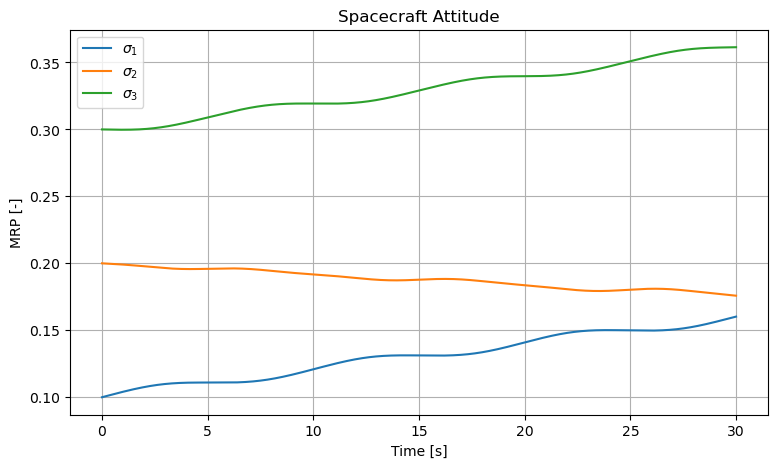

In [14]:
"""
Plot the spacecraft Modified Rodrigues Parameters over the simulation.

The three MRP components describe the evolving spacecraft attitude
sigma_BN relative to the inertial frame.
"""

time = solution.t

sigma_history = solution.y[0:3, :]

plt.figure(figsize=(9, 5))

plt.plot(time, sigma_history[0], label=r"$\sigma_1$")
plt.plot(time, sigma_history[1], label=r"$\sigma_2$")
plt.plot(time, sigma_history[2], label=r"$\sigma_3$")

plt.xlabel("Time [s]")
plt.ylabel("MRP [-]")
plt.title("Spacecraft Attitude")
plt.grid(True)
plt.legend()

plt.show()

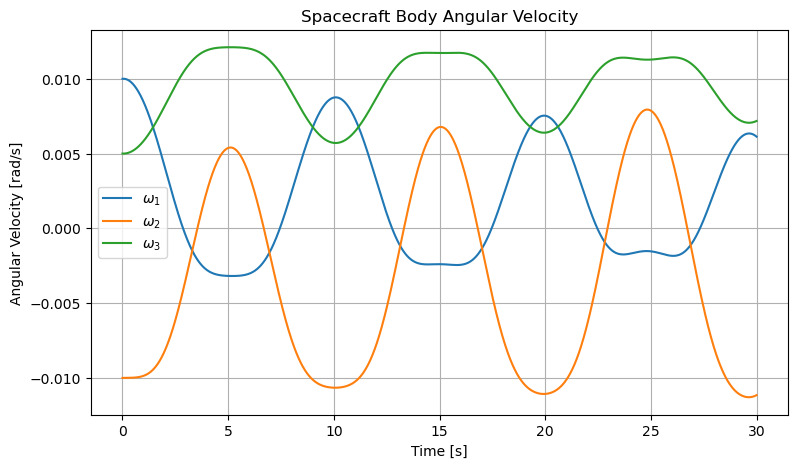

In [15]:
"""
Plot the spacecraft angular-velocity components expressed in B.

These rates evolve even though no external torque is applied because
angular momentum is exchanged internally with the VSCMG.
"""

omega_history = solution.y[3:6, :]

plt.figure(figsize=(9, 5))

plt.plot(time, omega_history[0], label=r"$\omega_1$")
plt.plot(time, omega_history[1], label=r"$\omega_2$")
plt.plot(time, omega_history[2], label=r"$\omega_3$")

plt.xlabel("Time [s]")
plt.ylabel("Angular Velocity [rad/s]")
plt.title("Spacecraft Body Angular Velocity")
plt.grid(True)
plt.legend()

plt.show()

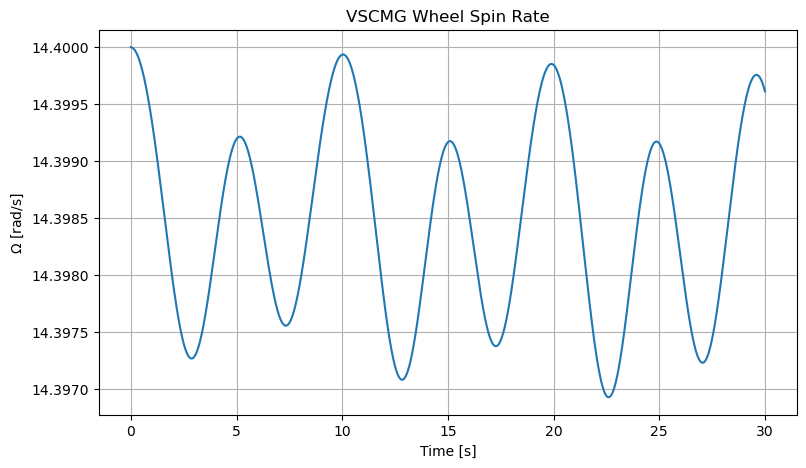

In [16]:
"""
Plot the VSCMG wheel spin rate.

Even with zero wheel motor torque, the wheel speed is not mathematically
forced to remain constant because the wheel remains dynamically coupled
to the moving spacecraft and gimbal.
"""

Omega_history = solution.y[8, :]

plt.figure(figsize=(9, 5))

plt.plot(time, Omega_history)

plt.xlabel("Time [s]")
plt.ylabel(r"$\Omega$ [rad/s]")
plt.title("VSCMG Wheel Spin Rate")
plt.grid(True)

plt.show()

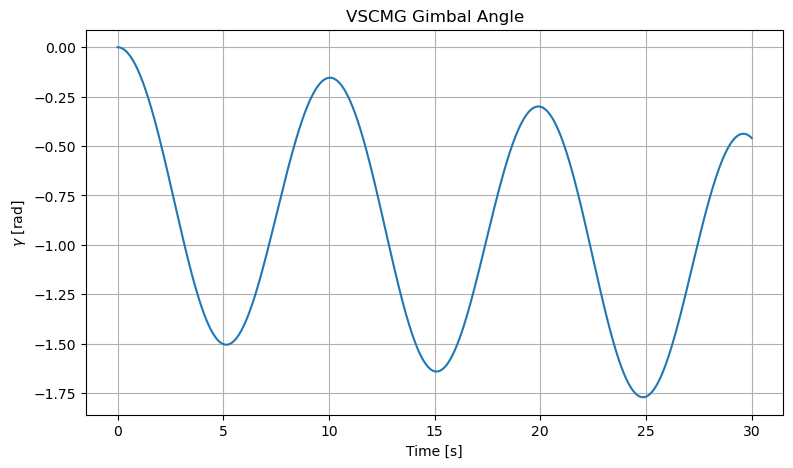

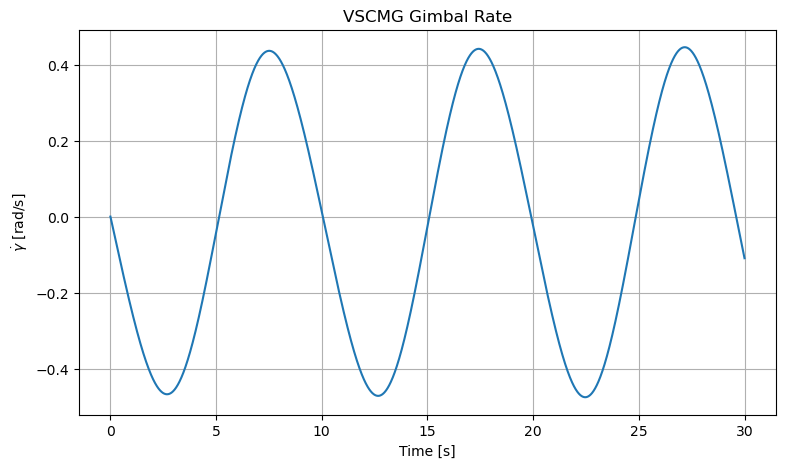

In [17]:
"""
Plot the VSCMG gimbal motion.

The zero gimbal motor torque does not lock the gimbal. The gimbal is a
free dynamic degree of freedom and responds to the gyroscopic coupling
within the spacecraft/VSCMG system.
"""

gamma_history = solution.y[6, :]
gamma_dot_history = solution.y[7, :]

plt.figure(figsize=(9, 5))

plt.plot(time, gamma_history)

plt.xlabel("Time [s]")
plt.ylabel(r"$\gamma$ [rad]")
plt.title("VSCMG Gimbal Angle")
plt.grid(True)

plt.show()


plt.figure(figsize=(9, 5))

plt.plot(time, gamma_dot_history)

plt.xlabel("Time [s]")
plt.ylabel(r"$\dot{\gamma}$ [rad/s]")
plt.title("VSCMG Gimbal Rate")
plt.grid(True)

plt.show()

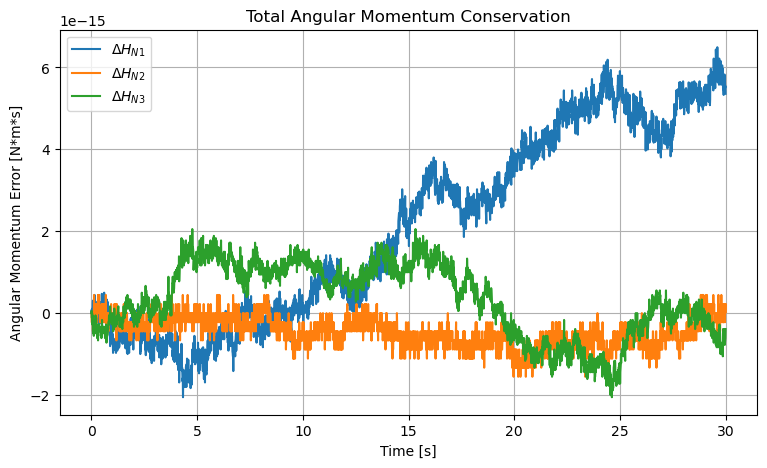

In [18]:
"""
Plot the inertial angular-momentum conservation error.

With zero external torque,

    dH_N/dt = 0.

Therefore each inertial component of the total angular momentum should
remain constant. Any observed drift here is numerical error.
"""

plt.figure(figsize=(9, 5))

plt.plot(time, H_error_history[:, 0], label=r"$\Delta H_{N1}$")
plt.plot(time, H_error_history[:, 1], label=r"$\Delta H_{N2}$")
plt.plot(time, H_error_history[:, 2], label=r"$\Delta H_{N3}$")

plt.xlabel("Time [s]")
plt.ylabel("Angular Momentum Error [N*m*s]")
plt.title("Total Angular Momentum Conservation")
plt.grid(True)
plt.legend()

plt.show()

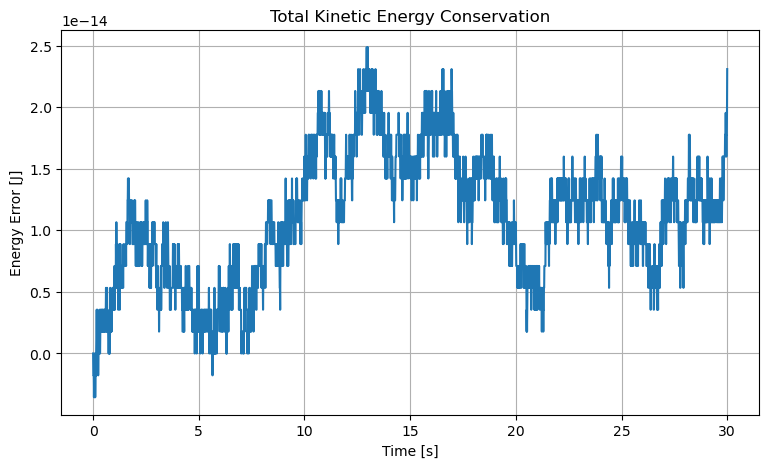

In [19]:
"""
Plot the kinetic-energy conservation error.

The work-energy relation gives

    T_dot = omega^T L + gamma_dot*u_g + Omega*u_s.

For this simulation,

    L = 0
    u_g = 0
    u_s = 0

so T_dot = 0 and the total kinetic energy should remain constant.
"""

plt.figure(figsize=(9, 5))

plt.plot(time, T_error_history)

plt.xlabel("Time [s]")
plt.ylabel("Energy Error [J]")
plt.title("Total Kinetic Energy Conservation")
plt.grid(True)

plt.show()

In [20]:
"""
Extract the required verification quantities at t_f = 30 seconds.

Required quiz outputs:

    H_N        : total angular momentum expressed in N [N*m*s]
    T          : total kinetic energy [J]
    sigma_BN   : spacecraft attitude MRPs [-]
    omega_BN_B : spacecraft angular velocity expressed in B [rad/s]
    Omega      : wheel spin rate [rad/s]
    gamma      : gimbal angle [rad]

The MRP shadow transformation is applied to the final attitude so that
the reported attitude uses the short-rotation / principal MRP set.
"""

# Final propagated state
x_f = solution.y[:, -1]

# Spacecraft attitude, principal MRP set [-]
sigma_BN = ak.MRP_shadow(x_f[0:3])

# Spacecraft angular velocity expressed in B [rad/s]
omega_BN_B = x_f[3:6]

# Gimbal angle [rad]
gamma = x_f[6]

# Gimbal rate [rad/s]
gamma_dot = x_f[7]

# Wheel spin rate [rad/s]
Omega = x_f[8]

# Total angular momentum expressed in N [N*m*s]
H_N = total_angular_momentum_N(
    sigma_BN=sigma_BN,
    omega_BN_B=omega_BN_B,
    Omega=Omega,
    gamma=gamma,
    gamma_dot=gamma_dot
)

# Total kinetic energy [J]
T = total_kinetic_energy(
    omega_BN_B=omega_BN_B,
    Omega=Omega,
    gamma=gamma,
    gamma_dot=gamma_dot
)

print(f"Results at t_f = {solution.t[-1]:.1f} s")
print("-" * 60)

print("H_N [N*m*s] =")
print(H_N)

print("\nT [J] =")
print(T)

print("\nsigma_BN [-] =")
print(sigma_BN)

print("\nomega_BN_B [rad/s] =")
print(omega_BN_B)

print("\nOmega [rad/s] =")
print(Omega)

print("\ngamma [rad] =")
print(gamma)

Results at t_f = 30.0 s
------------------------------------------------------------
H_N [N*m*s] =
[0.18038596 1.07456123 0.46786442]

T [J] =
10.36357101442844

sigma_BN [-] =
[0.16020254 0.17581713 0.36139187]

omega_BN_B [rad/s] =
[ 0.00613048 -0.01115198  0.00717923]

Omega [rad/s] =
14.399612994027407

gamma [rad] =
-0.4594161725874419


# 2 - Multi-VSCMG Modeling

## 2.1 - Extending the Model to Multiple VSCMGs

The single-VSCMG model developed in Section 1 gave us more than just the solution to one numerical problem. In constructing it, we already separated several ideas that naturally appear in a larger spacecraft simulation: fixed hardware properties, mounting geometry, dynamic states, equations of motion, numerical integration, and post-processing.

This section takes that single-device implementation and asks how those pieces can be reorganized into a small reusable simulation architecture that can support an arbitrary number of momentum exchange devices.

This is **not intended to become a full spacecraft 6DOF simulator**. A true six-degree-of-freedom model would at minimum couple the spacecraft's translational and rotational motion, while a more complete spacecraft simulation would normally also introduce environmental models, sensors, actuator models, state estimation, flight-software logic, timing, and other subsystems. Those topics are well beyond the scope of this notebook.

Instead, the goal here is much narrower: build a lightweight attitude-dynamics framework around the momentum-exchange-device problem we have already derived.

It can therefore be thought of loosely as a **6DOF-lite architecture**: not because it models all six spacecraft degrees of freedom, but because it begins to adopt some of the same software-design ideas that a larger simulator would require.

The development will focus on

$$
\boxed{
\text{device definition}
\rightarrow
\text{spacecraft model}
\rightarrow
\text{state}
\rightarrow
\text{dynamics}
\rightarrow
\text{integration}
\rightarrow
\text{verification}
}
$$

The objective is to keep every software abstraction close enough to the equations that the physical meaning remains visible. These tools can then serve as groundwork for a more complete 6DOF implementation should that thread be pursued later.

### 2.1.1 - The RK4 Integrator

Before introducing any new spacecraft or momentum-device objects, we can reuse a numerical tool developed previously.

In the first specialization, the classical fourth-order Runge-Kutta method was implemented as a generic single-step integrator. The important design choice was that the integrator itself contained no spacecraft dynamics. It only required a function capable of evaluating a first-order system of the form

$$
\boxed{
\dot{\mathbf{x}} = f(t,\mathbf{x}).
}
$$

The meaning and size of $\mathbf{x}$ are therefore irrelevant to RK4. In the previous attitude-control problem, the state contained the spacecraft MRPs and body rates. In the present problem, the same integrator can later propagate a larger state containing the spacecraft attitude, body rates, and the internal states of multiple momentum exchange devices.

The classical RK4 update evaluates the state derivative four times,

$$
\mathbf{k}_1 = f(t_k,\mathbf{x}_k),
$$

$$
\mathbf{k}_2 = f\left(t_k+\frac{\Delta t}{2},\mathbf{x}_k+\frac{\Delta t}{2}\mathbf{k}_1\right),
$$

$$
\mathbf{k}_3 = f\left(t_k+\frac{\Delta t}{2},\mathbf{x}_k+\frac{\Delta t}{2}\mathbf{k}_2\right),
$$

$$
\mathbf{k}_4 = f\left(t_k+\Delta t,\mathbf{x}_k+\Delta t\,\mathbf{k}_3\right),
$$

and combines them as

$$
\boxed{
\mathbf{x}_{k+1} =
\mathbf{x}_k
+
\frac{\Delta t}{6}
\left(
\mathbf{k}_1
+
2\mathbf{k}_2
+
2\mathbf{k}_3
+
\mathbf{k}_4
\right).
}
$$

This separation between the **numerical integrator** and the **state-derivative model** is useful because the dynamics can become considerably more complicated without requiring any change to the RK4 algorithm itself.

For this notebook, a fixed-step RK4 integrator is retained because it is transparent, deterministic, and sufficiently accurate for studying the coupled attitude and momentum-device dynamics. This should not be interpreted as RK4 being the preferred integrator for every spacecraft simulation. Step-size control, computational cost, stiffness, conservation properties, and long-duration numerical behaviour can all influence the choice of integration method.

> **TODO - Numerical Integration Study:**  
> A separate study should compare fixed- and variable-step integration methods, including Euler, RK2, RK4, adaptive Runge-Kutta methods, higher-order schemes such as DOP853, and structure-preserving methods for rotational dynamics. Particular attention should be given to accuracy, computational cost, timestep sensitivity, and conservation of mechanical invariants. This study is tracked separately under `studies/Numerical Integration Methods/`.

In [21]:
def rk4_step(f, t, x, dt, *args, **kwargs):
    """
    Advance one timestep using classical 4th-order Runge–Kutta (RK4).
    
    Parameters
    ----------
    f : callable
        RHS function with signature f(t, x, *args, **kwargs) -> xdot.
    t : float
        Current time.
    x : np.ndarray
        Current state vector.
    dt : float
        Timestep size.
    *args, **kwargs
        Extra arguments passed through to `f`.
    
    Returns
    -------
    x_next : np.ndarray
        State advanced by one RK4 step of size `dt`.
    """
    k1 = f(t, x, *args, **kwargs)
    k2 = f(t + 0.5*dt, x + 0.5*dt*k1, *args, **kwargs)
    k3 = f(t + 0.5*dt, x + 0.5*dt*k2, *args, **kwargs)
    k4 = f(t + dt, x + dt*k3, *args, **kwargs)
    
    x_next = x + (dt/6.0)*(k1 + 2*k2 + 2*k3 + k4)
    
    return x_next

### 2.1.2 - The `MomentumExchangeDevice` object

The first physical building block of the attitude model is a single momentum exchange device.

Although reaction wheels, CMGs, and VSCMGs differ in which internal motions are available, they share much of the same underlying description: inertial properties, a spin axis, and a fixed mounting orientation relative to the spacecraft. We can therefore use a common object to represent their fixed hardware properties, while allowing the device mode to determine how its internal states are treated later.

For the VSCMG model developed in Section 1, the principal inertias of the combined gimbal-wheel assembly are

$$ {}^G[J] = \operatorname{diag}(J_s,J_t,J_g), $$

which can be stored compactly as

$$ \mathbf{J}_G = (J_s,J_t,J_g). $$

The wheel spin-axis inertia $I_{W_s}$ is retained separately because it appears explicitly in the wheel momentum and motor dynamics.

The reference mounting orientation is described by

$$ \boxed{C_{BG_0} = \begin{bmatrix}\hat{\mathbf g}_{s_0,B} & \hat{\mathbf g}_{t_0,B} & \hat{\mathbf g}_{g,B}\end{bmatrix}}, $$

where $C_{BG_0}$ defines the device frame when $\gamma=0$. The first, second, and third columns therefore contain the reference spin, transverse, and gimbal axes expressed in the spacecraft body frame.

For a reaction wheel, this reference frame simply describes its fixed mounting orientation; there is no active gimbal motion. For a CMG or VSCMG, the current spin and transverse axes are obtained by rotating this reference frame through the current gimbal angle $\gamma$.

The device object should therefore contain only quantities that describe **what the hardware is**. Dynamic quantities such as $\gamma$, $\dot{\gamma}$, and $\Omega$ are intentionally excluded because they belong to the propagated system state.

In [22]:
from dataclasses import dataclass
from typing import Literal


@dataclass
class MomentumExchangeDevice:
    """
    Define the fixed properties and geometry of a momentum exchange device.

    Parameters
    ----------
    mode : {"RW", "CMG", "VSCMG"}
        Momentum exchange device type.
    J_G : tuple[float, float, float]
        Principal inertias (J_s, J_t, J_g) of the combined gimbal-wheel
        assembly expressed in the device frame [kg*m^2].
    I_Ws : float
        Wheel spin-axis moment of inertia [kg*m^2].
    C_BG_ref : np.ndarray
        Reference device-frame orientation relative to the spacecraft body
        frame at gamma = 0. Its columns are (g_s_ref_B, g_t_ref_B, g_g_B).
    """

    mode: Literal["RW", "CMG", "VSCMG"]
    J_G: tuple[float, float, float]
    I_Ws: float
    C_BG_ref: np.ndarray

    def __post_init__(self):
        self.J_G = tuple(float(J) for J in self.J_G)
        self.I_Ws = float(self.I_Ws)
        self.C_BG_ref = np.asarray(self.C_BG_ref, dtype=float)

        if self.mode not in ("RW", "CMG", "VSCMG"):
            raise ValueError("mode must be 'RW', 'CMG', or 'VSCMG'.")

        if len(self.J_G) != 3:
            raise ValueError("J_G must contain (J_s, J_t, J_g).")

        if any(J <= 0.0 for J in self.J_G):
            raise ValueError("All principal inertias in J_G must be positive.")

        if self.I_Ws <= 0.0:
            raise ValueError("I_Ws must be positive.")

        if self.C_BG_ref.shape != (3, 3):
            raise ValueError("C_BG_ref must be a 3x3 DCM.")

        if not np.allclose(self.C_BG_ref.T @ self.C_BG_ref, np.eye(3)):
            raise ValueError("C_BG_ref must be orthogonal.")

        if not np.isclose(np.linalg.det(self.C_BG_ref), 1.0):
            raise ValueError("C_BG_ref must be a proper rotation matrix.")

    @property
    def J_s(self):
        return self.J_G[0]

    @property
    def J_t(self):
        return self.J_G[1]

    @property
    def J_g(self):
        return self.J_G[2]

    @property
    def g_s_ref_B(self):
        return self.C_BG_ref[:, 0]

    @property
    def g_t_ref_B(self):
        return self.C_BG_ref[:, 1]

    @property
    def g_g_B(self):
        return self.C_BG_ref[:, 2]

    def axes_B(self, gamma):
        """
        Return the instantaneous device axes expressed in the body frame.

        Parameters
        ----------
        gamma : float
            Gimbal angle measured from the reference orientation [rad].

        Returns
        -------
        g_s_B, g_t_B, g_g_B : np.ndarray
            Spin, transverse, and gimbal unit vectors expressed in B.
        """
        g_s_B = np.cos(gamma)*self.g_s_ref_B + np.sin(gamma)*self.g_t_ref_B
        g_t_B = -np.sin(gamma)*self.g_s_ref_B + np.cos(gamma)*self.g_t_ref_B
        g_g_B = self.g_g_B
        return g_s_B, g_t_B, g_g_B

    def C_BG(self, gamma):
        """
        Return the instantaneous device-frame DCM relative to the body frame.

        Parameters
        ----------
        gamma : float
            Gimbal angle measured from the reference orientation [rad].

        Returns
        -------
        C_BG : np.ndarray
            Instantaneous device-frame DCM.
        """
        g_s_B, g_t_B, g_g_B = self.axes_B(gamma)
        C_BG = np.column_stack((g_s_B, g_t_B, g_g_B))
        return C_BG

    def inertia_B(self, gamma):
        """
        Return the combined device inertia expressed in the body frame.

        Parameters
        ----------
        gamma : float
            Gimbal angle measured from the reference orientation [rad].

        Returns
        -------
        J_B : np.ndarray
            Device inertia tensor expressed in B [kg*m^2].
        """
        C_BG = self.C_BG(gamma)
        J_G = np.diag(self.J_G)
        J_B = C_BG @ J_G @ C_BG.T
        return J_B

In [23]:
"""
Example usage of the MomentumExchangeDevice object using the single-VSCMG
configuration introduced previously.
"""

theta = np.deg2rad(54.75)

# Reference device axes expressed in the spacecraft body frame
g_s_ref_B = np.array([0.0, 1.0, 0.0])
g_g_B = np.array([np.cos(theta), 0.0, np.sin(theta)])
g_t_ref_B = np.cross(g_g_B, g_s_ref_B)

# Reference device-frame orientation at gamma = 0
C_BG_ref = np.column_stack((g_s_ref_B, g_t_ref_B, g_g_B))

# Instantiate the momentum exchange device
vscmg = MomentumExchangeDevice(
    mode="VSCMG",
    J_G=(0.13, 0.04, 0.03),
    I_Ws=0.10,
    C_BG_ref=C_BG_ref
)

# Evaluate the device geometry at a sample gimbal angle
gamma = np.deg2rad(30.0)

g_s_B, g_t_B, g_g_B = vscmg.axes_B(gamma)
C_BG = vscmg.C_BG(gamma)
J_B = vscmg.inertia_B(gamma)

print(f"Device mode:\n{vscmg.mode}")
print(f"\nPrincipal inertias [kg*m^2]:\n{vscmg.J_G}")
print(f"\nWheel spin-axis inertia [kg*m^2]:\n{vscmg.I_Ws}")

print(f"\nReference orientation C_BG_ref:\n{vscmg.C_BG_ref}")

print(f"\nInstantaneous geometry at gamma = {np.rad2deg(gamma):.1f} deg:")
print("g_s_B =", g_s_B)
print("g_t_B =", g_t_B)
print("g_g_B =", g_g_B)

print(f"\nInstantaneous orientation C_BG:\n{C_BG}")

print(f"\nDevice inertia expressed in B [kg*m^2]:\n{J_B}")

Device mode:
VSCMG

Principal inertias [kg*m^2]:
(0.13, 0.04, 0.03)

Wheel spin-axis inertia [kg*m^2]:
0.1

Reference orientation C_BG_ref:
[[ 0.         -0.81664156  0.57714519]
 [ 1.          0.          0.        ]
 [ 0.          0.57714519  0.81664156]]

Instantaneous geometry at gamma = 30.0 deg:
g_s_B = [-0.40832078  0.8660254   0.2885726 ]
g_t_B = [-0.70723233 -0.5         0.4998224 ]
g_g_B = [0.57714519 0.         0.81664156]

Instantaneous orientation C_BG:
[[-0.40832078 -0.70723233  0.57714519]
 [ 0.8660254  -0.5         0.        ]
 [ 0.2885726   0.4998224   0.81664156]]

Device inertia expressed in B [kg*m^2]:
[[ 0.05167436 -0.03182545 -0.01531792]
 [-0.03182545  0.1075      0.02249201]
 [-0.01531792  0.02249201  0.04082564]]


### 2.1.3 - State Representation

Before defining the spacecraft dynamics, the quantities being propagated must first be specified. For this notebook, the state contains the spacecraft attitude and body rate together with the internal states of each momentum exchange device.

For $N$ momentum exchange devices, define

$$
\boldsymbol{\gamma} =
\begin{bmatrix}
\gamma_1 & \gamma_2 & \cdots & \gamma_N
\end{bmatrix}^T,
$$

$$
\dot{\boldsymbol{\gamma}} =
\begin{bmatrix}
\dot{\gamma}_1 & \dot{\gamma}_2 & \cdots & \dot{\gamma}_N
\end{bmatrix}^T,
$$

$$
\boldsymbol{\Omega} =
\begin{bmatrix}
\Omega_1 & \Omega_2 & \cdots & \Omega_N
\end{bmatrix}^T.
$$

The complete state vector is then

$$
\boxed{
\mathbf{x} =
\begin{bmatrix}
\boldsymbol{\sigma}_{B/N} \\
{}^B\boldsymbol{\omega}_{B/N} \\
\boldsymbol{\gamma} \\
\dot{\boldsymbol{\gamma}} \\
\boldsymbol{\Omega}
\end{bmatrix}
\in \mathbb{R}^{6+3N}.
}
$$

The dimension follows directly from the states being propagated,

$$
\underbrace{3}_{\boldsymbol{\sigma}_{B/N}}
+
\underbrace{3}_{{}^B\boldsymbol{\omega}_{B/N}}
+
\underbrace{N}_{\gamma_i}
+
\underbrace{N}_{\dot{\gamma}_i}
+
\underbrace{N}_{\Omega_i} =
\boxed{6+3N}.
$$

The corresponding state derivative is

$$
\boxed{
\dot{\mathbf{x}} =
\begin{bmatrix}
\dot{\boldsymbol{\sigma}}_{B/N} \\
{}^B\dot{\boldsymbol{\omega}}_{B/N} \\
\dot{\boldsymbol{\gamma}} \\
\ddot{\boldsymbol{\gamma}} \\
\dot{\boldsymbol{\Omega}}
\end{bmatrix}.
}
$$

This state definition is kept separate from both the physical model and the numerical integrator. The `SpacecraftAttitudeModel` determines how the state evolves,

$$
\boxed{
\dot{\mathbf{x}} =
f(t,\mathbf{x},\mathbf{u}),
}
$$

while RK4 only advances the resulting state vector through time.

The small `pack_state()` and `unpack_state()` utilities below keep this state layout explicit without repeating numerical array indices throughout the dynamics model.

In [24]:
def pack_state(sigma_BN, omega_BN_B, gamma, gamma_dot, Omega):
    """
    Pack the spacecraft and momentum-device states into a single state vector.

    Parameters
    ----------
    sigma_BN : np.ndarray
        Spacecraft MRPs relative to the inertial frame.
    omega_BN_B : np.ndarray
        Spacecraft body angular velocity [rad/s].
    gamma : np.ndarray
        Device gimbal angles [rad].
    gamma_dot : np.ndarray
        Device gimbal rates [rad/s].
    Omega : np.ndarray
        Device wheel speeds [rad/s].

    Returns
    -------
    x : np.ndarray
        Packed state vector with ordering
        [sigma_BN, omega_BN_B, gamma, gamma_dot, Omega].
    """
    sigma_BN   = np.asarray(sigma_BN, dtype=float)
    omega_BN_B = np.asarray(omega_BN_B, dtype=float)
    gamma      = np.atleast_1d(np.asarray(gamma, dtype=float))
    gamma_dot  = np.atleast_1d(np.asarray(gamma_dot, dtype=float))
    Omega      = np.atleast_1d(np.asarray(Omega, dtype=float))

    if sigma_BN.shape != (3,):
        raise ValueError("sigma_BN must contain three elements.")

    if omega_BN_B.shape != (3,):
        raise ValueError("omega_BN_B must contain three elements.")

    if not (gamma.size == gamma_dot.size == Omega.size):
        raise ValueError("gamma, gamma_dot, and Omega must have equal length.")

    x = np.hstack((sigma_BN, omega_BN_B, gamma, gamma_dot, Omega))
    return x

In [25]:
def unpack_state(x, N):
    """
    Unpack the spacecraft and momentum-device state vector.

    Parameters
    ----------
    x : np.ndarray
        Packed state vector with ordering
        [sigma_BN, omega_BN_B, gamma, gamma_dot, Omega].
    N : int
        Number of momentum exchange devices represented in the state.

    Returns
    -------
    sigma_BN : np.ndarray
        Spacecraft MRPs relative to the inertial frame.
    omega_BN_B : np.ndarray
        Spacecraft body angular velocity [rad/s].
    gamma : np.ndarray
        Device gimbal angles [rad].
    gamma_dot : np.ndarray
        Device gimbal rates [rad/s].
    Omega : np.ndarray
        Device wheel speeds [rad/s].
    """
    x = np.asarray(x, dtype=float)

    if x.ndim != 1:
        raise ValueError("x must be a one-dimensional state vector.")

    if x.size != 6 + 3*N:
        raise ValueError(f"x must contain {6 + 3*N} elements for N = {N}.")

    sigma_BN   = x[0:3]
    omega_BN_B = x[3:6]
    gamma      = x[6:6 + N]
    gamma_dot  = x[6 + N:6 + 2*N]
    Omega      = x[6 + 2*N:6 + 3*N]

    return sigma_BN, omega_BN_B, gamma, gamma_dot, Omega

### 2.1.4 - The `SpacecraftAttitudeModel` object

A single `MomentumExchangeDevice` describes one actuator. The `SpacecraftAttitudeModel` brings the spacecraft hub and a collection of these devices together into one coupled rotational model.

The fixed configuration is defined by the spacecraft hub inertia $[I_s]$ and the set of mounted momentum exchange devices,

$$
\boxed{
\text{SpacecraftAttitudeModel} =
[I_s]
+
\left\{
\text{MomentumExchangeDevice}_i
\right\}_{i=1}^{N}.
}
$$

Since a CMG or VSCMG changes orientation as its gimbal rotates, each device contributes an inertia $[J_i](\gamma_i)$ that depends on its current gimbal angle. The instantaneous inertia of the complete spacecraft-device system is therefore

$$
\boxed{
[I](\boldsymbol{\gamma}) =
[I_s]
+
\sum_{i=1}^{N}
[J_i](\gamma_i).
}
$$

The model does not store the evolving spacecraft state internally. Instead, it interprets the state representation defined previously and evaluates

$$
\boxed{
\dot{\mathbf{x}} = f(t,\mathbf{x},\mathbf{u}).
}
$$

The MRP kinematics are obtained directly from

$$
\boxed{
\dot{\boldsymbol{\sigma}}_{B/N} = \frac{1}{4} [B(\boldsymbol{\sigma}_{B/N})] {}^B\boldsymbol{\omega}_{B/N}.
}
$$

The remaining quantities,

$$
{}^B\dot{\boldsymbol{\omega}}_{B/N},
\qquad
\dot{\boldsymbol{\Omega}},
\qquad
\ddot{\boldsymbol{\gamma}},
$$

must be solved simultaneously because the spacecraft, wheels, and gimbals exchange angular momentum with one another.

Define the unknown acceleration vector as

$$
\boxed{
\mathbf{a} =
\begin{bmatrix}
{}^B\dot{\boldsymbol{\omega}}_{B/N} \\
\dot{\boldsymbol{\Omega}} \\
\ddot{\boldsymbol{\gamma}}
\end{bmatrix}
\in
\mathbb{R}^{3+2N}.
}
$$

The coupled equations of motion can then be written as

$$
\boxed{
[M]\mathbf{a} = \mathbf{r}.
}
$$

Collect the instantaneous spin and gimbal axes into

$$
[G_s] =
\begin{bmatrix}
\hat{\mathbf g}_{s_1} &
\cdots &
\hat{\mathbf g}_{s_N}
\end{bmatrix},
$$

$$
[G_g] =
\begin{bmatrix}
\hat{\mathbf g}_{g_1} &
\cdots &
\hat{\mathbf g}_{g_N}
\end{bmatrix},
$$

and define the diagonal inertia matrices

$$
[D_W] =
\operatorname{diag}
\left(
I_{W_{s_1}},
\ldots,
I_{W_{s_N}}
\right),
$$

$$
[D_g] =
\operatorname{diag}
\left(
J_{g_1},
\ldots,
J_{g_N}
\right).
$$

For $N$ VSCMGs, the coupled system has the block structure

$$
\boxed{
[M] =
\begin{bmatrix}
[I] & [G_s][D_W] & [G_g][D_g] \\
[D_W][G_s]^T & [D_W] & [0] \\
[D_g][G_g]^T & [0] & [D_g]
\end{bmatrix}.
}
$$

The first three rows contain the spacecraft rotational equations of motion, the next $N$ rows contain the wheel equations, and the final $N$ rows contain the gimbal equations. The system therefore contains $3+2N$ equations for the $3+2N$ unknown accelerations.

The block matrix is assembled directly inside `solve_coupled_eom()`. The spacecraft inertia is inserted using

```python
M[0:3, 0:3] = I_B
```

while the contribution of device $i$ to the spacecraft equations is inserted using

```python
M[0:3, i_Omega] = device.I_Ws*g_s_B
M[0:3, i_gamma] = device.J_g*g_g_B
```

corresponding to the $i$th columns of $[G_s][D_W]$ and $[G_g][D_g]$.

The wheel equation contributes

```python
M[wheel_row, 0:3] = device.I_Ws*g_s_B
M[wheel_row, i_Omega] = device.I_Ws
```

while the gimbal equation contributes

```python
M[gimbal_row, 0:3] = device.J_g*g_g_B
M[gimbal_row, i_gamma] = device.J_g
```

The remaining nonlinear terms and applied torques are collected in the right-hand side $\mathbf{r}$. The coupled accelerations are then obtained using

```python
accelerations = np.linalg.solve(M, rhs)
```

rather than explicitly computing $[M]^{-1}$.

The device `mode` determines which internal degrees of freedom remain dynamic,

$$
\begin{array}{c|cc}
\text{Mode} & \dot{\Omega}_i & \ddot{\gamma}_i \\
\hline
\text{RW} & \text{solved} & 0 \\
\text{CMG} & 0 & \text{solved} \\
\text{VSCMG} & \text{solved} & \text{solved}
\end{array}
$$

with a constrained equation replaced by the corresponding identity row in $[M]$.

The important distinction is

$$
\boxed{
\text{fixed state}
\neq
\text{zero state}.
}
$$

A CMG may therefore operate at a non-zero wheel speed while satisfying $\dot{\Omega}_i=0$, while a reaction wheel may remain at a fixed gimbal angle while satisfying $\dot{\gamma}_i=\ddot{\gamma}_i=0$.

The `SpacecraftAttitudeModel` therefore provides three main operations,

```python
attitude_model.inertia_B(gamma)
attitude_model.solve_coupled_eom(...)
attitude_model.state_derivative(...)
```

which respectively evaluate the instantaneous inertia, solve the coupled rotational dynamics, and evaluate the complete state derivative.

The numerical integrator remains separate from the physical model. It only receives

$$
\boxed{
\dot{\mathbf{x}} = f(t,\mathbf{x},\mathbf{u}),
}
$$

and advances the externally maintained state through time.

In [26]:
class SpacecraftAttitudeModel:
    """
    Model the coupled rotational dynamics of a spacecraft and its
    momentum exchange devices.

    Parameters
    ----------
    I_s_B : np.ndarray
        Spacecraft hub inertia expressed in B, excluding the momentum
        exchange devices [kg*m^2].
    devices : list[MomentumExchangeDevice]
        Momentum exchange devices mounted to the spacecraft.
    """

    def __init__(self, I_s_B, devices):
        self.I_s_B = np.asarray(I_s_B, dtype=float)
        self.devices = list(devices)

        if self.I_s_B.shape != (3, 3):
            raise ValueError("I_s_B must be a 3x3 inertia tensor.")
        if not np.allclose(self.I_s_B, self.I_s_B.T):
            raise ValueError("I_s_B must be symmetric.")
        if np.any(np.linalg.eigvalsh(self.I_s_B) <= 0.0):
            raise ValueError("I_s_B must be positive definite.")
        if not all(isinstance(device, MomentumExchangeDevice) for device in self.devices):
            raise TypeError("All devices must be MomentumExchangeDevice objects.")

    @property
    def num_devices(self):
        """Return the number of momentum exchange devices."""
        return len(self.devices)

    def inertia_B(self, gamma):
        """
        Compute the total spacecraft-device inertia expressed in B.

        Parameters
        ----------
        gamma : np.ndarray
            Gimbal angle of each momentum exchange device [rad].

        Returns
        -------
        I_B : np.ndarray
            Instantaneous total inertia tensor [kg*m^2].
        """
        gamma = np.atleast_1d(np.asarray(gamma, dtype=float))

        if gamma.size != self.num_devices:
            raise ValueError("gamma must contain one value per device.")

        I_B = self.I_s_B.copy()

        for device, gamma_i in zip(self.devices, gamma):
            I_B += device.inertia_B(gamma_i)

        return I_B

    def solve_coupled_eom(self, omega_BN_B, gamma, gamma_dot, Omega,
                          L_B=None, u_s=None, u_g=None):
        """
        Solve the coupled spacecraft and momentum-device equations of motion.

        Parameters
        ----------
        omega_BN_B : np.ndarray
            Spacecraft angular velocity expressed in B [rad/s].
        gamma : np.ndarray
            Device gimbal angles [rad].
        gamma_dot : np.ndarray
            Device gimbal rates [rad/s].
        Omega : np.ndarray
            Device wheel speeds [rad/s].
        L_B : np.ndarray, optional
            External torque expressed in B [N*m].
        u_s : np.ndarray, optional
            Wheel motor torques [N*m].
        u_g : np.ndarray, optional
            Gimbal motor torques [N*m].

        Returns
        -------
        omega_dot_B : np.ndarray
            Spacecraft angular acceleration expressed in B [rad/s^2].
        Omega_dot : np.ndarray
            Device wheel accelerations [rad/s^2].
        gamma_ddot : np.ndarray
            Device gimbal accelerations [rad/s^2].
        """
        N = self.num_devices

        omega_BN_B = np.asarray(omega_BN_B, dtype=float)
        gamma = np.atleast_1d(np.asarray(gamma, dtype=float))
        gamma_dot = np.atleast_1d(np.asarray(gamma_dot, dtype=float))
        Omega = np.atleast_1d(np.asarray(Omega, dtype=float))

        if omega_BN_B.shape != (3,):
            raise ValueError("omega_BN_B must contain three elements.")
        if not (gamma.size == gamma_dot.size == Omega.size == N):
            raise ValueError("gamma, gamma_dot, and Omega must contain one value per device.")

        L_B = np.zeros(3) if L_B is None else np.asarray(L_B, dtype=float)
        u_s = np.zeros(N) if u_s is None else np.atleast_1d(np.asarray(u_s, dtype=float))
        u_g = np.zeros(N) if u_g is None else np.atleast_1d(np.asarray(u_g, dtype=float))

        if L_B.shape != (3,):
            raise ValueError("L_B must contain three elements.")
        if u_s.size != N or u_g.size != N:
            raise ValueError("u_s and u_g must contain one value per device.")

        I_B = self.inertia_B(gamma)

        # Unknown acceleration vector:
        # a = [omega_dot_B, Omega_dot, gamma_ddot]
        M = np.zeros((3 + 2*N, 3 + 2*N))
        rhs = np.zeros(3 + 2*N)

        # Spacecraft rotational EOM
        M[0:3, 0:3] = I_B
        rhs[0:3] = -np.cross(omega_BN_B, I_B @ omega_BN_B) + L_B

        for i, device in enumerate(self.devices):
            # Device properties
            J_s = device.J_s
            J_t = device.J_t
            J_g = device.J_g
            I_Ws = device.I_Ws

            # Device states
            gamma_i = gamma[i]
            gamma_dot_i = gamma_dot[i]
            Omega_i = Omega[i]

            # Instantaneous device axes
            g_s_B, g_t_B, g_g_B = device.axes_B(gamma_i)

            # Spacecraft angular velocity resolved in the device frame
            omega_s = g_s_B @ omega_BN_B
            omega_t = g_t_B @ omega_BN_B
            omega_g = g_g_B @ omega_BN_B

            # Reaction-wheel gimbal is locked
            if device.mode == "RW":
                if not np.isclose(gamma_dot_i, 0.0):
                    raise ValueError(f"RW device {i} requires gamma_dot = 0.")
                gamma_dot_i = 0.0

            # Matrix column and row indices
            i_Omega = 3 + i
            i_gamma = 3 + N + i
            wheel_row = 3 + i
            gimbal_row = 3 + N + i

            # Device contribution to spacecraft rotational EOM
            M[0:3, i_Omega] = I_Ws*g_s_B
            M[0:3, i_gamma] = J_g*g_g_B

            rhs[0:3] -= g_s_B*(J_s - J_t + J_g)*gamma_dot_i*omega_t
            rhs[0:3] -= g_t_B*(
                ((J_s - J_t - J_g)*omega_s + I_Ws*Omega_i)*gamma_dot_i
                + I_Ws*Omega_i*omega_g
            )
            rhs[0:3] += g_g_B*I_Ws*Omega_i*omega_t

            # Wheel EOM: dynamic for RW/VSCMG, fixed-speed constraint for CMG
            if device.mode == "CMG":
                M[wheel_row, i_Omega] = 1.0
                rhs[wheel_row] = 0.0
            else:
                M[wheel_row, 0:3] = I_Ws*g_s_B
                M[wheel_row, i_Omega] = I_Ws
                rhs[wheel_row] = u_s[i] - I_Ws*gamma_dot_i*omega_t

            # Gimbal EOM: dynamic for CMG/VSCMG, locked constraint for RW
            if device.mode == "RW":
                M[gimbal_row, i_gamma] = 1.0
                rhs[gimbal_row] = 0.0
            else:
                M[gimbal_row, 0:3] = J_g*g_g_B
                M[gimbal_row, i_gamma] = J_g
                rhs[gimbal_row] = (
                    u_g[i]
                    + (J_s - J_t)*omega_s*omega_t
                    + I_Ws*Omega_i*omega_t
                )

        # Solve M*a = rhs
        accelerations = np.linalg.solve(M, rhs)

        omega_dot_B = accelerations[0:3]
        Omega_dot = accelerations[3:3 + N]
        gamma_ddot = accelerations[3 + N:3 + 2*N]

        return omega_dot_B, Omega_dot, gamma_ddot

    def state_derivative(self, t, x, input_function=None):
        """
        Evaluate the state derivative for the supplied spacecraft state.

        Parameters
        ----------
        t : float
            Current simulation time [s].
        x : np.ndarray
            State vector defined by the state representation in Section 2.1.3.
        input_function : callable, optional
            Function with signature input_function(t, x) returning
            (L_B, u_s, u_g).

        Returns
        -------
        x_dot : np.ndarray
            State derivative corresponding to x.
        """
        N = self.num_devices
        sigma_BN, omega_BN_B, gamma, gamma_dot, Omega = unpack_state(x, N)

        # External and motor torques
        if input_function is None:
            L_B = np.zeros(3)
            u_s = np.zeros(N)
            u_g = np.zeros(N)
        else:
            L_B, u_s, u_g = input_function(t, x)

        # MRP kinematics
        sigma_dot_BN = 0.25*ak.Bmat_MRP(sigma_BN) @ omega_BN_B

        # Coupled spacecraft and momentum-device dynamics
        omega_dot_B, Omega_dot, gamma_ddot = self.solve_coupled_eom(
            omega_BN_B,
            gamma,
            gamma_dot,
            Omega,
            L_B=L_B,
            u_s=u_s,
            u_g=u_g
        )

        # gamma_dot propagates gamma; an RW gimbal remains locked
        gamma_rate = gamma_dot.copy()

        for i, device in enumerate(self.devices):
            if device.mode == "RW":
                gamma_rate[i] = 0.0

        x_dot = np.hstack((
            sigma_dot_BN,
            omega_dot_B,
            gamma_rate,
            gamma_ddot,
            Omega_dot
        ))

        return x_dot

    def angular_momentum_B(self, x):
        """
        Compute the total spacecraft-device angular momentum expressed in B.

        Parameters
        ----------
        x : np.ndarray
            Spacecraft and momentum-device state vector.

        Returns
        -------
        H_B : np.ndarray
            Total angular momentum expressed in B [N*m*s].
        """
        N = self.num_devices
        _, omega_BN_B, gamma, gamma_dot, Omega = unpack_state(x, N)

        I_B = self.inertia_B(gamma)
        H_B = I_B @ omega_BN_B

        for i, device in enumerate(self.devices):
            J_g = device.J_g
            I_Ws = device.I_Ws

            gamma_dot_i = gamma_dot[i]
            Omega_i = Omega[i]

            g_s_B, _, g_g_B = device.axes_B(gamma[i])

            if device.mode == "RW":
                if not np.isclose(gamma_dot_i, 0.0):
                    raise ValueError(f"RW device {i} requires gamma_dot = 0.")
                gamma_dot_i = 0.0

            H_B += J_g*gamma_dot_i*g_g_B + I_Ws*Omega_i*g_s_B

        return H_B

    def angular_momentum_N(self, x):
        """
        Compute the total spacecraft-device angular momentum expressed in N.

        Parameters
        ----------
        x : np.ndarray
            Spacecraft and momentum-device state vector.

        Returns
        -------
        H_N : np.ndarray
            Total angular momentum expressed in N [N*m*s].
        """
        sigma_BN, _, _, _, _ = unpack_state(x, self.num_devices)

        H_B = self.angular_momentum_B(x)
        C_BN = ak.MRP_to_DCM(sigma_BN)

        H_N = C_BN.T @ H_B
        return H_N

    def kinetic_energy(self, x):
        """
        Compute the total rotational kinetic energy of the spacecraft-device system.

        Parameters
        ----------
        x : np.ndarray
            Spacecraft and momentum-device state vector.

        Returns
        -------
        T : float
            Total rotational kinetic energy [J].
        """
        N = self.num_devices
        _, omega_BN_B, gamma, gamma_dot, Omega = unpack_state(x, N)

        # Spacecraft hub contribution
        T = 0.5*omega_BN_B @ self.I_s_B @ omega_BN_B

        for i, device in enumerate(self.devices):
            J_s = device.J_s
            J_t = device.J_t
            J_g = device.J_g
            I_Ws = device.I_Ws

            gamma_dot_i = gamma_dot[i]
            Omega_i = Omega[i]

            g_s_B, g_t_B, g_g_B = device.axes_B(gamma[i])

            omega_s = g_s_B @ omega_BN_B
            omega_t = g_t_B @ omega_BN_B
            omega_g = g_g_B @ omega_BN_B

            if device.mode == "RW":
                if not np.isclose(gamma_dot_i, 0.0):
                    raise ValueError(f"RW device {i} requires gamma_dot = 0.")
                gamma_dot_i = 0.0

            T += 0.5*(
                J_s*omega_s**2
                + J_t*omega_t**2
                + J_g*(omega_g + gamma_dot_i)**2
                + 2.0*I_Ws*Omega_i*omega_s
                + I_Ws*Omega_i**2
            )

        return float(T)

### 2.1.5 - Simulation Driver

In [27]:
def simulate_attitude_dynamics(model, x_0, t_0, t_f, dt, input_function=None):
    """
    Propagate a spacecraft attitude model and collect simulation histories.

    Parameters
    ----------
    model : SpacecraftAttitudeModel
        Spacecraft attitude model to propagate.
    x_0 : np.ndarray
        Initial spacecraft and momentum-device state vector.
    t_0 : float
        Initial simulation time [s].
    t_f : float
        Final simulation time [s].
    dt : float
        Nominal fixed integration timestep [s].
    input_function : callable, optional
        Function with signature input_function(t, x) returning
        (L_B, u_s, u_g).

    Returns
    -------
    results : dict
        Time, state, and diagnostic histories from the simulation.
    """
    if t_f <= t_0:
        raise ValueError("t_f must be greater than t_0.")
    if dt <= 0.0:
        raise ValueError("dt must be positive.")
    if input_function is not None and not callable(input_function):
        raise TypeError("input_function must be callable or None.")

    N = model.num_devices
    x = np.asarray(x_0, dtype=float).copy()

    # Validate the initial state against the model configuration
    sigma_BN, omega_BN_B, gamma, gamma_dot, Omega = unpack_state(x, N)

    # Construct the simulation time grid
    time = np.arange(t_0, t_f, dt, dtype=float)
    time = np.append(time, t_f)

    num_samples = time.size

    # Allocate state and diagnostic histories
    state_history = np.zeros((num_samples, x.size))
    sigma_BN_history = np.zeros((num_samples, 3))
    omega_BN_B_history = np.zeros((num_samples, 3))
    gamma_history = np.zeros((num_samples, N))
    gamma_dot_history = np.zeros((num_samples, N))
    Omega_history = np.zeros((num_samples, N))
    H_N_history = np.zeros((num_samples, 3))
    T_history = np.zeros(num_samples)

    # Store the initial condition
    state_history[0] = x
    sigma_BN_history[0] = sigma_BN
    omega_BN_B_history[0] = omega_BN_B
    gamma_history[0] = gamma
    gamma_dot_history[0] = gamma_dot
    Omega_history[0] = Omega
    H_N_history[0] = model.angular_momentum_N(x)
    T_history[0] = model.kinetic_energy(x)

    # Propagate the state
    for k in range(num_samples - 1):
        dt_k = time[k + 1] - time[k]

        x = rk4_step(
            model.state_derivative,
            time[k],
            x,
            dt_k,
            input_function
        )

        # Apply MRP shadow switching only after the accepted integration step
        x[0:3] = ak.MRP_shadow(x[0:3])

        sigma_BN, omega_BN_B, gamma, gamma_dot, Omega = unpack_state(x, N)

        # Store the propagated state
        state_history[k + 1] = x
        sigma_BN_history[k + 1] = sigma_BN
        omega_BN_B_history[k + 1] = omega_BN_B
        gamma_history[k + 1] = gamma
        gamma_dot_history[k + 1] = gamma_dot
        Omega_history[k + 1] = Omega

        # Store physical diagnostics
        H_N_history[k + 1] = model.angular_momentum_N(x)
        T_history[k + 1] = model.kinetic_energy(x)

    results = {
        "time": time,
        "state": state_history,
        "sigma_BN": sigma_BN_history,
        "omega_BN_B": omega_BN_B_history,
        "gamma": gamma_history,
        "gamma_dot": gamma_dot_history,
        "Omega": Omega_history,
        "H_N": H_N_history,
        "T": T_history,
    }

    return results

## 2.2 - 4-VSCMG Numerical Simulation (and Debugging)

In [28]:
# Spacecraft hub inertia [kg*m^2]
I_s_B = np.diag([86.0, 85.0, 113.0])

# VSCMG inertia properties [kg*m^2]
J_G = (0.13, 0.04, 0.03)
I_Ws = 0.10

N = 4
theta = np.deg2rad(54.75)

# Initial spacecraft attitude and body rate
sigma_BN_0 = np.array([0.1, 0.2, 0.3])
omega_BN_B_0 = np.array([0.01, -0.01, 0.005])

# Initial VSCMG states
gamma_0 = np.deg2rad([0.0, 0.0, 90.0, -90.0])
gamma_dot_0 = np.zeros(N)
Omega_0 = np.full(N, 14.4)

# Initial VSCMG gimbal axes expressed in B
g_g_B = np.array([
    [ np.cos(theta),  0.0,            np.sin(theta)],
    [-np.cos(theta),  0.0,            np.sin(theta)],
    [ 0.0,             np.cos(theta), np.sin(theta)],
    [ 0.0,            -np.cos(theta), np.sin(theta)]
])

# Initial VSCMG spin axes expressed in B
g_s_B_0 = np.array([
    [ 0.0,  1.0, 0.0],
    [ 0.0, -1.0, 0.0],
    [ 1.0,  0.0, 0.0],
    [-1.0,  0.0, 0.0]
])

In [29]:
def reference_dcm_from_initial_axes(g_s_B_0, g_g_B, gamma_0):
    """
    Recover the reference device-frame DCM from its initial orientation.

    Parameters
    ----------
    g_s_B_0 : np.ndarray
        Spin axis expressed in B at the initial gimbal angle.
    g_g_B : np.ndarray
        Gimbal axis expressed in B.
    gamma_0 : float
        Initial gimbal angle [rad].

    Returns
    -------
    C_BG_ref : np.ndarray
        Device-frame DCM relative to B at gamma = 0.
    """
    g_t_B_0 = np.cross(g_g_B, g_s_B_0)

    g_s_ref_B = np.cos(gamma_0)*g_s_B_0 - np.sin(gamma_0)*g_t_B_0
    g_t_ref_B = np.sin(gamma_0)*g_s_B_0 + np.cos(gamma_0)*g_t_B_0

    C_BG_ref = np.column_stack((g_s_ref_B, g_t_ref_B, g_g_B))
    return C_BG_ref

In [30]:
devices = []

for i in range(N):
    C_BG_ref = reference_dcm_from_initial_axes(
        g_s_B_0[i],
        g_g_B[i],
        gamma_0[i]
    )

    vscmg = MomentumExchangeDevice(
        mode="VSCMG",
        J_G=J_G,
        I_Ws=I_Ws,
        C_BG_ref=C_BG_ref
    )

    devices.append(vscmg)

for i, device in enumerate(devices):
    g_s_B, _, g_g_B_i = device.axes_B(gamma_0[i])

    print(
        f"VSCMG {i + 1}: "
        f"spin-axis error = {np.linalg.norm(g_s_B - g_s_B_0[i]):.3e}, "
        f"gimbal-axis error = {np.linalg.norm(g_g_B_i - g_g_B[i]):.3e}"
    )

VSCMG 1: spin-axis error = 0.000e+00, gimbal-axis error = 0.000e+00
VSCMG 2: spin-axis error = 0.000e+00, gimbal-axis error = 0.000e+00
VSCMG 3: spin-axis error = 0.000e+00, gimbal-axis error = 0.000e+00
VSCMG 4: spin-axis error = 0.000e+00, gimbal-axis error = 0.000e+00


In [31]:
attitude_model = SpacecraftAttitudeModel(
    I_s_B=I_s_B,
    devices=devices
)

print(f"Number of momentum exchange devices: {attitude_model.num_devices}")
print("Initial total inertia [kg*m^2]:")
print(attitude_model.inertia_B(gamma_0))

Number of momentum exchange devices: 4
Initial total inertia [kg*m^2]:
[[ 86.33333807   0.           0.        ]
 [  0.          85.33333807   0.        ]
 [  0.           0.         113.13332386]]


In [32]:
x_0 = pack_state(
    sigma_BN=sigma_BN_0,
    omega_BN_B=omega_BN_B_0,
    gamma=gamma_0,
    gamma_dot=gamma_dot_0,
    Omega=Omega_0
)

print(f"State dimension: {x_0.size}")
print(f"Expected dimension: {6 + 3*N}")
print(x_0)

State dimension: 18
Expected dimension: 18
[ 1.00000000e-01  2.00000000e-01  3.00000000e-01  1.00000000e-02
 -1.00000000e-02  5.00000000e-03  0.00000000e+00  0.00000000e+00
  1.57079633e+00 -1.57079633e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  1.44000000e+01  1.44000000e+01
  1.44000000e+01  1.44000000e+01]


In [33]:
def zero_inputs(t, x):
    """Return zero external, wheel-motor, and gimbal-motor torques."""
    L_B = np.zeros(3)
    u_s = np.zeros(N)
    u_g = np.zeros(N)

    return L_B, u_s, u_g

In [34]:
t_0 = 0.0
t_f = 30.0
dt = 0.01

results = simulate_attitude_dynamics(
    model=attitude_model,
    x_0=x_0,
    t_0=t_0,
    t_f=t_f,
    dt=dt,
    input_function=zero_inputs
)

results

{'time': array([0.000e+00, 1.000e-02, 2.000e-02, ..., 2.998e+01, 2.999e+01,
        3.000e+01]),
 'state': array([[ 0.1       ,  0.2       ,  0.3       , ..., 14.4       ,
         14.4       , 14.4       ],
        [ 0.10004175,  0.1999915 ,  0.2999965 , ..., 14.400002  ,
         14.3999985 , 14.40000114],
        [ 0.1000835 ,  0.19998301,  0.299993  , ..., 14.4000045 ,
         14.39999749, 14.40000107],
        ...,
        [ 0.10919487,  0.19827476,  0.3164043 , ..., 14.40909377,
         14.40827862, 14.39180003],
        [ 0.10919994,  0.19827737,  0.31640716, ..., 14.40905862,
         14.40820776, 14.39185931],
        [ 0.10920522,  0.19828003,  0.31641011, ..., 14.40902333,
         14.40813619, 14.39191878]]),
 'sigma_BN': array([[0.1       , 0.2       , 0.3       ],
        [0.10004175, 0.1999915 , 0.2999965 ],
        [0.1000835 , 0.19998301, 0.299993  ],
        ...,
        [0.10919487, 0.19827476, 0.3164043 ],
        [0.10919994, 0.19827737, 0.31640716],
        [0.1

In [35]:
sigma_BN_f = results["sigma_BN"][-1]
omega_BN_B_f = results["omega_BN_B"][-1]
gamma_f = results["gamma"][-1]
gamma_dot_f = results["gamma_dot"][-1]
Omega_f = results["Omega"][-1]

H_N_f = results["H_N"][-1]
T_f = results["T"][-1]

np.set_printoptions(precision=10, suppress=True)

print("Final inertial angular momentum [N*m*s]:")
print(H_N_f)

print("\nFinal kinetic energy [J]:")
print(T_f)

print("\nFinal MRPs:")
print(sigma_BN_f)

print("\nFinal body rate [rad/s]:")
print(omega_BN_B_f)

print("\nFinal wheel speeds [rad/s]:")
print(Omega_f)

print("\nFinal gimbal angles [rad]:")
print(gamma_f)

print("\nFinal gimbal angles [deg]:")
print(np.rad2deg(gamma_f))

print("\nFinal gimbal rateas [rad/s]:")
print(gamma_dot_f)

Final inertial angular momentum [N*m*s]:
[ 1.148943272   0.5230060734 -0.4470963138]

Final kinetic energy [J]:
41.48199750035234

Final MRPs:
[0.1092052242 0.1982800331 0.316410115 ]

Final body rate [rad/s]:
[0.0016701023 0.0001051235 0.001630373 ]

Final wheel speeds [rad/s]:
[14.389803792  14.4090233328 14.4081361855 14.391918781 ]

Final gimbal angles [rad]:
[-0.2234050658  0.4826704375  0.9822076331 -1.2262317143]

Final gimbal angles [deg]:
[-12.8001673927  27.6549789634  56.2763519848 -70.2579019372]

Final gimbal rateas [rad/s]:
[ 0.1438856597 -0.6389408543  0.4637969517 -0.0408592477]


In [36]:
H_N_0 = results["H_N"][0]
H_N_f = results["H_N"][-1]

T_0 = results["T"][0]
T_f = results["T"][-1]

delta_H_N = H_N_f - H_N_0
delta_H_norm = np.linalg.norm(delta_H_N)

delta_T = T_f - T_0

print("Initial angular momentum [N*m*s]:")
print(H_N_0)

print("\nFinal angular momentum [N*m*s]:")
print(H_N_f)

print("\nAngular momentum change [N*m*s]:")
print(delta_H_N)

print(f"\n||Delta H_N|| = {delta_H_norm:.3e} N*m*s")

print(f"\nInitial kinetic energy = {T_0:.12f} J")
print(f"Final kinetic energy   = {T_f:.12f} J")
print(f"Delta T                = {delta_T:.3e} J")

Initial angular momentum [N*m*s]:
[ 1.148943272   0.5230060734 -0.4470963139]

Final angular momentum [N*m*s]:
[ 1.148943272   0.5230060734 -0.4470963138]

Angular momentum change [N*m*s]:
[-0. -0.  0.]

||Delta H_N|| = 4.115e-11 N*m*s

Initial kinetic energy = 41.481997500355 J
Final kinetic energy   = 41.481997500352 J
Delta T                = -2.807e-12 J


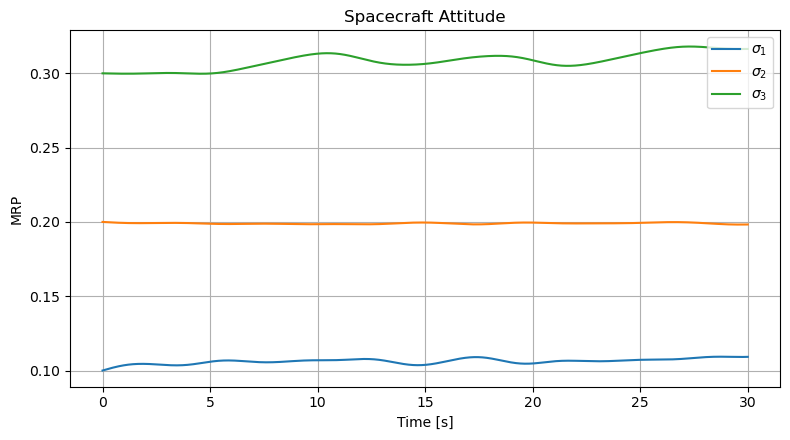

In [37]:
time = results["time"]

plt.figure(figsize=(8, 4.5))

plt.plot(time, results["sigma_BN"][:, 0], label=r"$\sigma_1$")
plt.plot(time, results["sigma_BN"][:, 1], label=r"$\sigma_2$")
plt.plot(time, results["sigma_BN"][:, 2], label=r"$\sigma_3$")

plt.xlabel("Time [s]")
plt.ylabel("MRP")
plt.title("Spacecraft Attitude")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

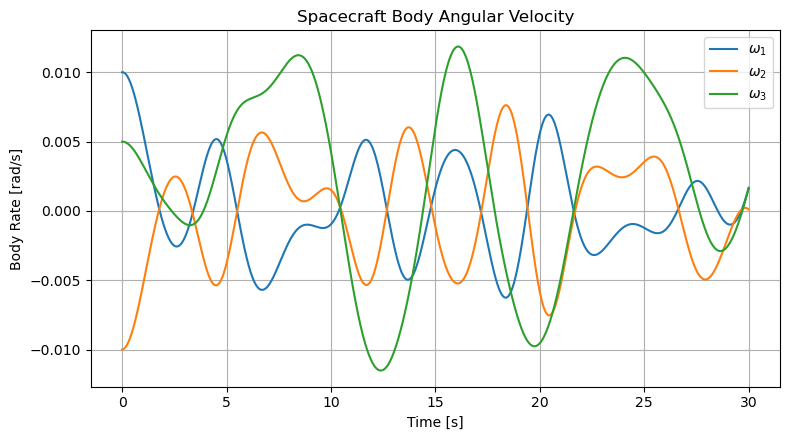

In [38]:
plt.figure(figsize=(8, 4.5))

plt.plot(time, results["omega_BN_B"][:, 0], label=r"$\omega_1$")
plt.plot(time, results["omega_BN_B"][:, 1], label=r"$\omega_2$")
plt.plot(time, results["omega_BN_B"][:, 2], label=r"$\omega_3$")

plt.xlabel("Time [s]")
plt.ylabel("Body Rate [rad/s]")
plt.title("Spacecraft Body Angular Velocity")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

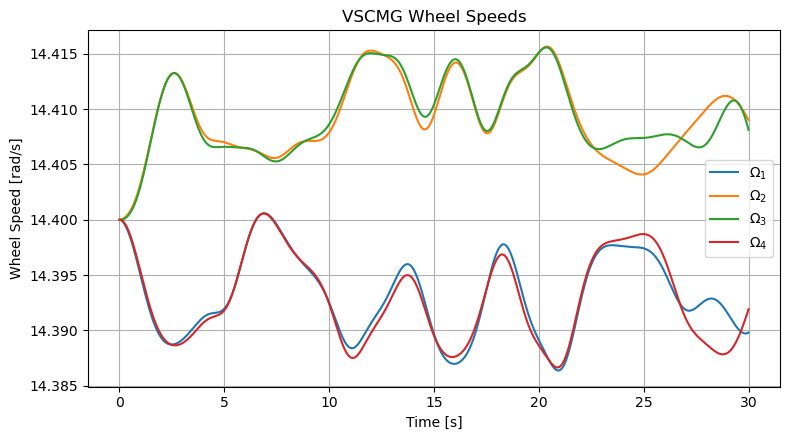

In [39]:
plt.figure(figsize=(8, 4.5))

for i in range(N):
    plt.plot(time, results["Omega"][:, i], label=rf"$\Omega_{i + 1}$")

plt.xlabel("Time [s]")
plt.ylabel("Wheel Speed [rad/s]")
plt.title("VSCMG Wheel Speeds")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

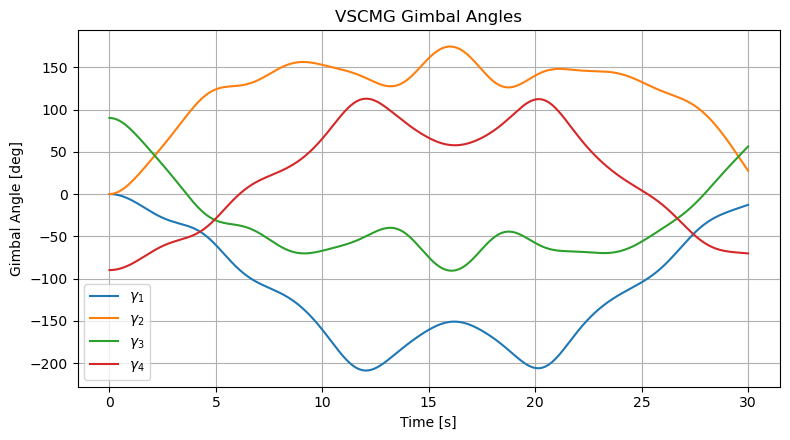

In [40]:
gamma_deg = np.rad2deg(results["gamma"])

plt.figure(figsize=(8, 4.5))

for i in range(N):
    plt.plot(time, gamma_deg[:, i], label=rf"$\gamma_{i + 1}$")

plt.xlabel("Time [s]")
plt.ylabel("Gimbal Angle [deg]")
plt.title("VSCMG Gimbal Angles")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

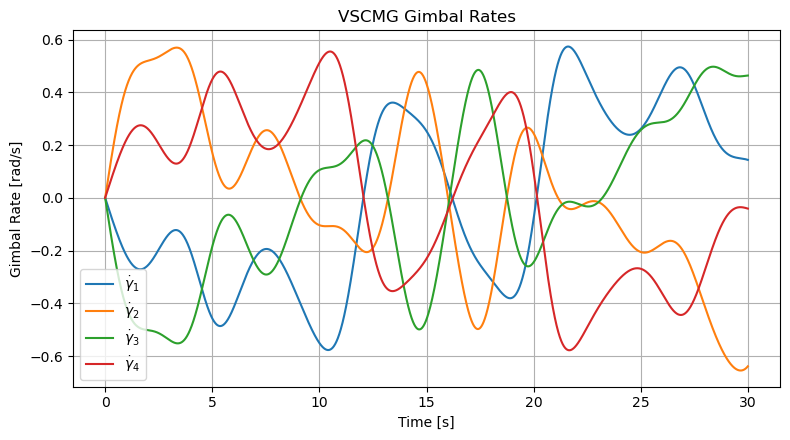

In [41]:
plt.figure(figsize=(8, 4.5))

for i in range(N):
    plt.plot(time, results["gamma_dot"][:, i], label=rf"$\dot{{\gamma}}_{i + 1}$")

plt.xlabel("Time [s]")
plt.ylabel("Gimbal Rate [rad/s]")
plt.title("VSCMG Gimbal Rates")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

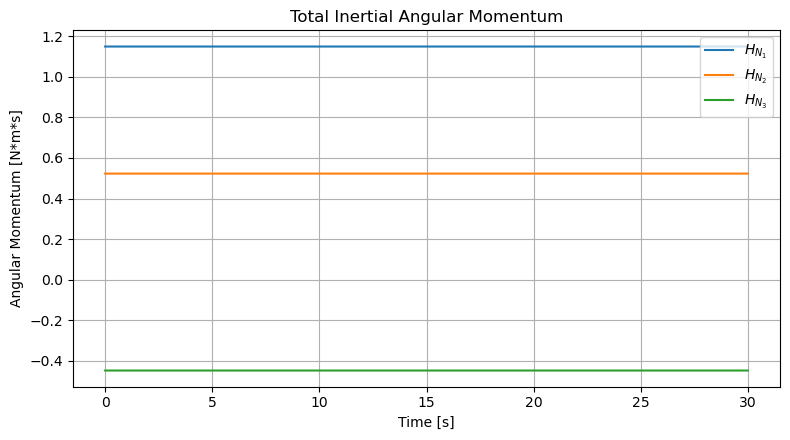

In [42]:
plt.figure(figsize=(8, 4.5))

plt.plot(time, results["H_N"][:, 0], label=r"$H_{N_1}$")
plt.plot(time, results["H_N"][:, 1], label=r"$H_{N_2}$")
plt.plot(time, results["H_N"][:, 2], label=r"$H_{N_3}$")

plt.xlabel("Time [s]")
plt.ylabel("Angular Momentum [N*m*s]")
plt.title("Total Inertial Angular Momentum")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

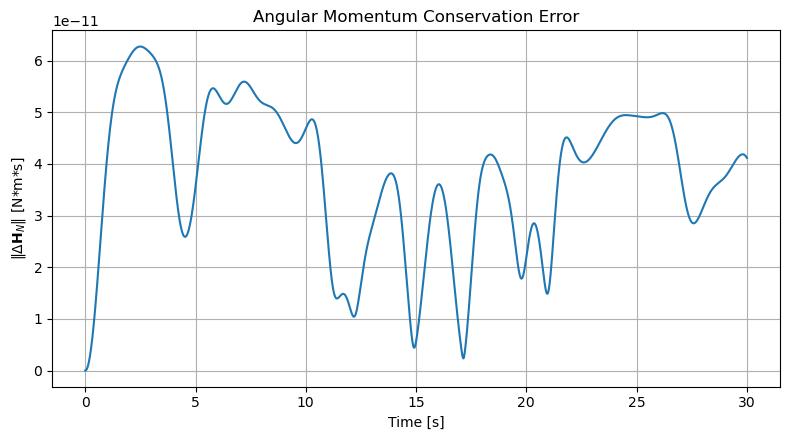

In [43]:
H_N_error = results["H_N"] - results["H_N"][0]
H_N_error_norm = np.linalg.norm(H_N_error, axis=1)

plt.figure(figsize=(8, 4.5))

plt.plot(time, H_N_error_norm)

plt.xlabel("Time [s]")
plt.ylabel(r"$\|\Delta\mathbf{H}_N\|$ [N*m*s]")
plt.title("Angular Momentum Conservation Error")
plt.grid(True)
plt.tight_layout()
plt.show()

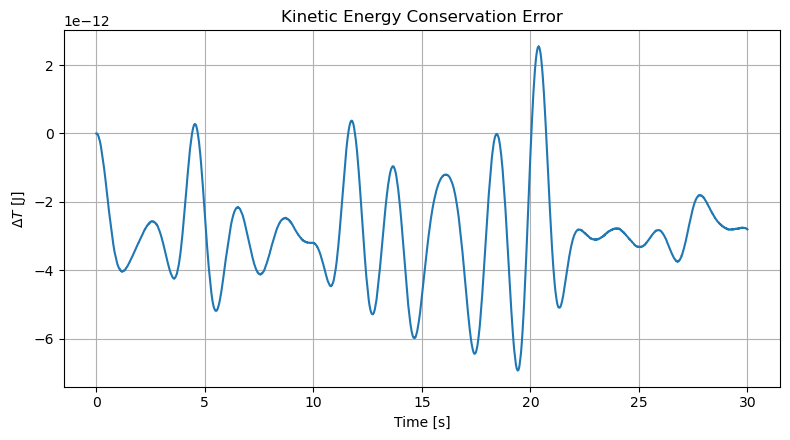

In [44]:
T_error = results["T"] - results["T"][0]

plt.figure(figsize=(8, 4.5))

plt.plot(time, T_error)

plt.xlabel("Time [s]")
plt.ylabel(r"$\Delta T$ [J]")
plt.title("Kinetic Energy Conservation Error")
plt.grid(True)
plt.tight_layout()
plt.show()

## 2.3 - Work-Energy Verification